# Week 7 — Performance Evaluation, Uncertainty, and Backtest Auditing

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/07/week7_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week7_main.ipynb` from GitHub and upload it to Colab.

This is the complete Week 7 lesson. It carries forward the Week 6 AAPL/MSFT request, close-to-close price-return convention, trading rules, position timing, one-way turnover, and instructor-created transaction-cost assumptions. The strategy is not changed when a new performance measure is introduced. This separation lets each issue ask what one measure adds and what it cannot establish.

The AAPL and MSFT prices and derived returns come from the recorded yfinance request. The commission, half-spread, slippage, cash return, strategy rules, and execution convention remain teaching assumptions. Daily yfinance data do not show an investor's orders, quotes, fills, taxes, financing, or realized trading costs. The buy-and-hold series remains a price-return benchmark because cash dividends are not added.

## Core financial question

After data, trading rules, execution, and costs are fixed, how should a historical strategy's return, risk, trading intensity, and statistical uncertainty be measured, and which conclusions remain unsupported?

Run the notebook from top to bottom. Before each code cell, record the requested prediction. After execution, retain the original prediction, cite the displayed values, and answer both discussion questions with a specific conclusion.


## Observable outcome

After completing Week 7, you will produce a common-condition performance table, wealth and drawdown records, a market-period sensitivity comparison, circular block-bootstrap intervals, a repeated-selection demonstration, and a backtest audit. Every result will identify the evaluated return series, period, frequency, target return, cost status, benchmark, and limits on interpretation.

## Learning objectives

After completing Week 7, you should be able to:

- distinguish periodic mean return, cumulative wealth, and compounded annualized return;
- calculate annualized volatility, Sharpe ratio, downside deviation, and Sortino ratio under declared conventions;
- construct running peaks and drawdowns and distinguish maximum drawdown depth, duration, and recovery;
- interpret turnover and gross-versus-net evidence beside return and risk measures;
- align candidate and benchmark returns before calculating benchmark-relative performance;
- compare prespecified market periods without treating a descriptive split as a causal regime explanation;
- use a circular block bootstrap to display sampling uncertainty under stated block-length, repetition, and seed assumptions;
- demonstrate how selection from many tried strategies can make the selected historical result optimistic; and
- audit a backtest and restrict each conclusion to the available evidence.

## Before you begin

Complete Week 6 or review its fixed cost-and-execution ledger. Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, `matplotlib`, and `yfinance`. Source-grounded cells require internet access in a fresh environment.

The 252-observation annualization factor is a teaching convention for the daily examples. It describes scale under a fixed sampling-frequency assumption; it is not a forecast and does not prove that returns are independent or identically distributed. The zero and 5% annual target returns used below are instructor-created comparison assumptions, not observed risk-free rates or approved Report 1 settings.


# Navigation through the twenty issues

| Section | Issues | Main decision | Evidence carried forward |
|---|---:|---|---|
| Return series and annualization | 1–4 | Which return series is evaluated, and how do mean, wealth, annualized return, and volatility differ? | Dated return series with frequency, units, cost status, and annualization convention |
| Target and downside-risk measures | 5–8 | Which target and denominator define each risk-adjusted measure? | Sharpe and Sortino calculations with explicit conventions |
| Drawdown, trading, and costs | 9–12 | What does the path reveal, and how do turnover and costs change the conclusion? | Drawdown episodes and gross-versus-net comparison |
| Benchmarks and period sensitivity | 13–16 | Are candidate and benchmark conditions compatible, and do results vary across prespecified periods? | Common-date performance table and period comparison |
| Uncertainty, selection, and audit | 17–20 | How do serial dependence, bootstrap assumptions, and repeated selection limit the claim? | Sensitivity intervals, selection record, and final audit |

```text
fixed dated return series and cost status
        ↓ summarize return and variability
target return and downside convention
        ↓ measure risk-adjusted performance
wealth path and running peak
        ↓ measure drawdown depth, duration, and recovery
common benchmark and prespecified periods
        ↓ compare under compatible conditions
dependence, resampling, and tried alternatives
        ↓ state the historical conclusion and its limits
```

Week 7 evaluates fixed candidate and benchmark paths. It does not choose or optimize portfolio weights. Equal weighting may appear only as a fixed Week 6 benchmark; weighting-method selection begins in Week 8.


# Preparation and fixed evaluation conditions

The source request starts on 2024-01-02 inclusive and ends before 2025-01-03. It uses daily `Close` observations with `auto_adjust=False` and calculates close-to-close price returns. The candidate holds AAPL when the five-session momentum signal observed at one close was positive; the held position is shifted one row so it applies to the next close-to-close return. The slower rule uses a twenty-session lookback.

The Week 6 teaching cost remains 4 basis points per unit of one-way turnover: 1 basis point commission, 2 basis points half-spread, and 1 basis point slippage. All three are assumptions. Cash has an assumed zero periodic return. Buy-and-hold pays the initial entry cost and has no terminal liquidation. The two timing rules pay the same rate on every position change and also have no terminal liquidation.

The notebook does not silently replace these conditions when a metric changes. If a team evaluates another strategy, it must record its own source, return convention, dates, frequency, position timing, cost components, benchmark, annualization factor, target return, and number of tried alternatives before interpreting the metrics.


In [1]:
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import yfinance as yf
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)
plt.rcParams.update(
    {
        "figure.figsize": (7.8, 3.9),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

SOURCE_REQUEST = {
    "start": "2024-01-02",
    "end": "2025-01-03",
    "interval": "1d",
    "auto_adjust": False,
    "actions": False,
    "progress": False,
    "threads": False,
    "multi_level_index": False,
}
PERIODS_PER_YEAR = 252
TEACHING_COMMISSION_BP = 1.0
TEACHING_FULL_SPREAD_BP = 4.0
TEACHING_HALF_SPREAD_BP = TEACHING_FULL_SPREAD_BP / 2
TEACHING_SLIPPAGE_BP = 1.0
TEACHING_TOTAL_ONE_WAY_BP = (
    TEACHING_COMMISSION_BP
    + TEACHING_HALF_SPREAD_BP
    + TEACHING_SLIPPAGE_BP
)


def load_us_daily(symbol):
    if yf is None:
        raise ModuleNotFoundError(
            "Install yfinance before running the source-grounded Week 7 examples."
        )
    rows = yf.download(tickers=symbol, **SOURCE_REQUEST)
    if isinstance(rows.columns, pd.MultiIndex):
        rows.columns = rows.columns.get_level_values(0)
    rows.index = pd.DatetimeIndex(rows.index).tz_localize(None)
    required = {"Open", "High", "Low", "Close", "Volume"}
    if rows.empty or not required.issubset(rows.columns):
        raise ValueError(f"The fixed {symbol} request returned no usable OHLCV response.")
    rows = rows.sort_index()
    if not rows.index.is_unique:
        raise ValueError(f"The fixed {symbol} response contains duplicate dates.")
    return rows


def one_way_turnover(position, initial_position=0.0):
    position = pd.Series(position, dtype=float)
    if position.empty or not np.isfinite(position).all():
        raise ValueError("Positions must be a nonempty finite series.")
    previous = position.shift(1)
    previous.iloc[0] = initial_position
    return (position - previous).abs()


def cost_ledger(position, asset_return, total_cost_bp, initial_position=0.0):
    position = pd.Series(position, dtype=float)
    asset_return = pd.Series(asset_return, dtype=float).reindex(position.index)
    if asset_return.isna().any() or not np.isfinite(asset_return).all():
        raise ValueError("Every held interval must have one finite asset return.")
    if not np.isfinite(total_cost_bp) or total_cost_bp < 0:
        raise ValueError("The one-way cost in basis points must be finite and nonnegative.")
    turnover = one_way_turnover(position, initial_position)
    gross_return = position * asset_return
    cost = turnover * total_cost_bp / 10_000
    net_return = gross_return - cost
    return pd.DataFrame(
        {
            "asset_return": asset_return,
            "position": position,
            "one_way_turnover": turnover,
            "gross_return": gross_return,
            "cost_return_units": cost,
            "net_return": net_return,
            "gross_wealth": (1 + gross_return).cumprod(),
            "net_wealth": (1 + net_return).cumprod(),
        }
    )


def show_figure_with_alt_text(figure, alt_text):
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}})
    plt.close(figure)


environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
        "Annualization factor": "252 observations per year (teaching convention)",
        "Cost values": "Instructor-created teaching assumptions",
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())


,Value
Environment item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0
Annualization factor,252 observations per year (teaching convention)
Cost values,Instructor-created teaching assumptions


In [2]:
aapl = load_us_daily("AAPL")
msft = load_us_daily("MSFT")

source_prices = pd.concat(
    {"AAPL": aapl["Close"], "MSFT": msft["Close"]}, axis=1, join="inner"
).dropna()
source_returns = source_prices.pct_change(fill_method=None).dropna()

aapl_frame = aapl[["Open", "Close"]].copy()
aapl_frame["asset_return"] = aapl_frame["Close"].pct_change(fill_method=None)
for lookback in [5, 20]:
    aapl_frame[f"momentum_{lookback}"] = (
        aapl_frame["Close"] / aapl_frame["Close"].shift(lookback) - 1
    )
    aapl_frame[f"signal_{lookback}"] = np.where(
        aapl_frame[f"momentum_{lookback}"].isna(),
        np.nan,
        (aapl_frame[f"momentum_{lookback}"] > 0).astype(float),
    )
    aapl_frame[f"position_{lookback}"] = pd.Series(
        aapl_frame[f"signal_{lookback}"], index=aapl_frame.index
    ).shift(1).fillna(0.0)

source_eval = aapl_frame.dropna(subset=["asset_return"]).copy()
candidate_ledger = cost_ledger(
    source_eval["position_5"],
    source_eval["asset_return"],
    TEACHING_TOTAL_ONE_WAY_BP,
)
slow_rule_ledger = cost_ledger(
    source_eval["position_20"],
    source_eval["asset_return"],
    TEACHING_TOTAL_ONE_WAY_BP,
)
buy_hold_ledger = cost_ledger(
    pd.Series(1.0, index=source_eval.index),
    source_eval["asset_return"],
    TEACHING_TOTAL_ONE_WAY_BP,
)
cash_return = pd.Series(0.0, index=source_eval.index, name="Cash net return")

real_net_returns = pd.DataFrame(
    {
        "AAPL five-session rule net": candidate_ledger["net_return"],
        "AAPL twenty-session rule net": slow_rule_ledger["net_return"],
        "AAPL buy-and-hold net": buy_hold_ledger["net_return"],
        "Cash net": cash_return,
    }
)
real_gross_returns = pd.DataFrame(
    {
        "AAPL five-session rule gross": candidate_ledger["gross_return"],
        "AAPL twenty-session rule gross": slow_rule_ledger["gross_return"],
        "AAPL buy-and-hold gross": buy_hold_ledger["gross_return"],
        "Cash gross": cash_return,
    }
)

request_summary = pd.Series(
    {
        "Symbols": "AAPL and MSFT",
        "Start boundary": "2024-01-02 inclusive",
        "End boundary": "2025-01-03 exclusive",
        "Observation interval": "1 day",
        "Price field used for returns": "Close",
        "auto_adjust": False,
        "Return meaning": "Close-to-close price return; cash dividends not added",
        "Candidate position": "Five-session momentum signal, shifted one row",
        "Total one-way cost": "4 basis points per unit of turnover (assumed)",
        "Terminal liquidation": "Not included",
    },
    name="Recorded setting",
)
display(request_summary.to_frame())

source_summary = pd.DataFrame(
    [
        ("AAPL", len(aapl), str(aapl.index.min().date()), str(aapl.index.max().date())),
        ("MSFT", len(msft), str(msft.index.min().date()), str(msft.index.max().date())),
        (
            "Common evaluation intervals",
            len(source_eval),
            str(source_eval.index.min().date()),
            str(source_eval.index.max().date()),
        ),
    ],
    columns=["Item", "Rows", "First date", "Last date"],
)
display(source_summary.style.hide(axis="index").set_caption(
    "Fixed US-stock requests and common Week 7 evaluation dates"
))

assert len(source_eval) == 252
assert real_net_returns.index.equals(real_gross_returns.index)
assert np.isfinite(real_net_returns.to_numpy()).all()


,Recorded setting
Symbols,AAPL and MSFT
Start boundary,2024-01-02 inclusive
End boundary,2025-01-03 exclusive
Observation interval,1 day
Price field used for returns,Close
auto_adjust,False
Return meaning,Close-to-close price return; cash dividends no...
Candidate position,"Five-session momentum signal, shifted one row"
Total one-way cost,4 basis points per unit of turnover (assumed)
Terminal liquidation,Not included


Item,Rows,First date,Last date
AAPL,253,2024-01-02,2025-01-02
MSFT,253,2024-01-02,2025-01-02
Common evaluation intervals,252,2024-01-03,2025-01-02


## Issue 1 — Which dated return series is being evaluated?


A performance number is interpretable only after the return series is identified. Record the asset or strategy, beginning and ending dates, interval represented by each row, observation frequency, price or total-return meaning, gross or net status, cost rule, initial holding, and terminal treatment. A label such as `strategy return` is not enough when those conditions are missing.

For a strategy with gross return $r^{gross}_t$, one-way turnover $u_t$, and assumed proportional one-way cost $c$, the Week 6 identity is

$$
r^{net}_t=r^{gross}_t-c u_t.
$$

The equality supports a calculation only when all three values refer to the same dated interval. It does not make the assumed cost an observed execution.

### Connection to documented sources

The [yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) documents the request interface. The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) emphasizes consistent return periods and clear gross- or net-of-fees status. This notebook does not claim GIPS compliance.

### Controlled example

The first example uses four instructor-created gross returns, positions, and a 4-basis-point one-way cost.

### Before Code 1

Predict which rows carry a cost deduction and calculate the largest net-return deduction in decimal return units.


In [3]:
controlled_issue_1 = pd.DataFrame(
    {
        "Asset return (decimal)": [0.010, -0.006, 0.012, 0.004],
        "Held position": [0.0, 1.0, 1.0, 0.0],
    },
    index=pd.bdate_range("2026-01-05", periods=4),
)
controlled_issue_1["One-way turnover"] = one_way_turnover(
    controlled_issue_1["Held position"]
)
controlled_issue_1["Cost deduction (decimal return)"] = (
    controlled_issue_1["One-way turnover"] * TEACHING_TOTAL_ONE_WAY_BP / 10_000
)
controlled_issue_1["Gross portfolio return (decimal)"] = (
    controlled_issue_1["Asset return (decimal)"]
    * controlled_issue_1["Held position"]
)
controlled_issue_1["Net return (decimal)"] = (
    controlled_issue_1["Gross portfolio return (decimal)"]
    - controlled_issue_1["Cost deduction (decimal return)"]
)
display(controlled_issue_1.style.format("{:.6f}").set_caption(
    "Artificial daily gross-to-net return record; 4 basis points per unit of one-way turnover"
))
assert np.allclose(
    controlled_issue_1["Net return (decimal)"],
    controlled_issue_1["Gross portfolio return (decimal)"]
    - controlled_issue_1["Cost deduction (decimal return)"],
)


,Asset return (decimal),Held position,One-way turnover,Cost deduction (decimal return),Gross portfolio return (decimal),Net return (decimal)
2026-01-05 00:00:00,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-01-06 00:00:00,-0.006000,1.000000,1.000000,0.000400,-0.006000,-0.006400
2026-01-07 00:00:00,0.012000,1.000000,0.000000,0.000000,0.012000,0.012000
2026-01-08 00:00:00,0.004000,0.000000,1.000000,0.000400,0.000000,-0.000400


### Interpret Code 1

The second and fourth rows change the held position by 1.0 and therefore each deduct 0.000400, or 4 basis points, from portfolio return. The first and third rows have zero turnover and zero cost deduction. The calculation is internally consistent under the teaching assumption; it does not show a measured commission, spread, or fill.

### Source-grounded example

Code 2 displays the evaluation identity of each source-derived AAPL path without showing downloaded market rows.

### Before Code 2

Predict whether all four methods have the same 252 return-ending dates and identify which columns represent assumed rather than source-provided information.


In [4]:
issue_1_real = pd.DataFrame(
    {
        "Method": real_net_returns.columns,
        "Observations": [real_net_returns[column].notna().sum() for column in real_net_returns],
        "First return-ending date": [str(real_net_returns.index.min().date())] * 4,
        "Last return-ending date": [str(real_net_returns.index.max().date())] * 4,
        "Return frequency": ["Daily"] * 4,
        "Return meaning": ["AAPL Close-to-Close price return"] * 3 + ["Assumed zero cash return"],
        "Cost status": ["4 bp one-way cost assumed"] * 3 + ["No cash cost assumed"],
        "Terminal liquidation": ["Not included"] * 4,
    }
)
display(issue_1_real.style.hide(axis="index").set_caption(
    "Week 7 evaluation identities and fixed conditions"
))
assert issue_1_real["Observations"].eq(252).all()


Method,Observations,First return-ending date,Last return-ending date,Return frequency,Return meaning,Cost status,Terminal liquidation
AAPL five-session rule net,252,2024-01-03,2025-01-02,Daily,AAPL Close-to-Close price return,4 bp one-way cost assumed,Not included
AAPL twenty-session rule net,252,2024-01-03,2025-01-02,Daily,AAPL Close-to-Close price return,4 bp one-way cost assumed,Not included
AAPL buy-and-hold net,252,2024-01-03,2025-01-02,Daily,AAPL Close-to-Close price return,4 bp one-way cost assumed,Not included
Cash net,252,2024-01-03,2025-01-02,Daily,Assumed zero cash return,No cash cost assumed,Not included


### Interpret Code 2

Every method has 252 daily return-ending observations from 2024-01-03 through 2025-01-02. The AAPL price returns are source-derived, while the positions, 4-basis-point cost, zero cash return, and no-liquidation convention are teaching assumptions. Common dates are necessary for comparison but do not make the execution assumptions observed facts.

### Discussion questions

1. A report states only “daily net return.” List the additional fields needed to reconstruct the evaluated series, then identify which missing field would prevent gross-to-net reconciliation.
2. Suppose a team adds cash dividends to buy-and-hold but leaves the candidate as a closing-price return. Decide whether the two 252-row series remain comparable and state the exact return convention that must be made common.


## Issue 2 — How do arithmetic mean return and cumulative wealth answer different questions?


The arithmetic mean describes the average observed one-period return. Cumulative wealth describes the compounded result of an ordered return path. They are not interchangeable because losses and gains multiply through wealth.

For $T$ periodic simple returns $r_1,\ldots,r_T$ and initial wealth $W_0=1$,

$$
\bar r=\frac{1}{T}\sum_{t=1}^{T}r_t,
\qquad
W_T=\prod_{t=1}^{T}(1+r_t),
\qquad
R_{0,T}=W_T-1.
$$

Every return must exceed -100% for wealth to remain positive. The mean does not retain the order of returns; the intermediate wealth path does.

### Connection to documented sources

The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) explains geometric linking of subperiod returns. The artificial example below illustrates the identity and is not a GIPS-compliant performance presentation.

### Controlled example

The first example uses +10% followed by -10%.

### Before Code 1

Predict the arithmetic mean, final wealth from USD 1.00 of normalized initial capital, and cumulative return.


,Value
Arithmetic mean periodic return (percent),0.00
Final normalized wealth,0.99
Cumulative return (percent),-1.00


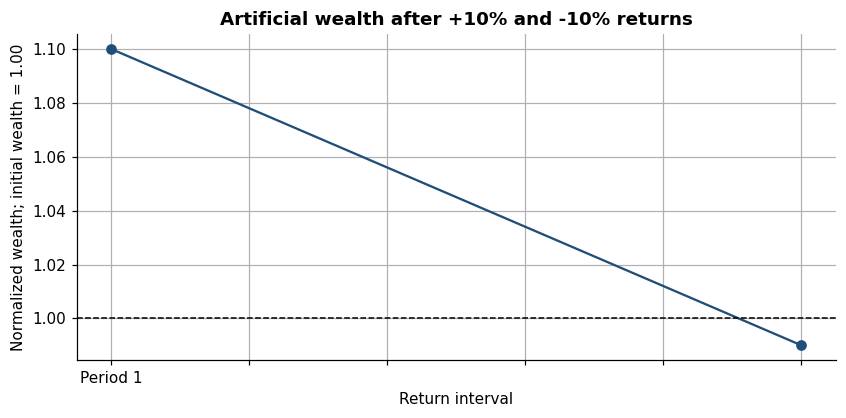

In [5]:
controlled_issue_2_return = pd.Series(
    [0.10, -0.10],
    index=["Period 1", "Period 2"],
    name="Periodic return (decimal)",
)
controlled_issue_2_wealth = (1 + controlled_issue_2_return).cumprod()
controlled_issue_2_summary = pd.Series(
    {
        "Arithmetic mean periodic return (percent)": controlled_issue_2_return.mean() * 100,
        "Final normalized wealth": controlled_issue_2_wealth.iloc[-1],
        "Cumulative return (percent)": (controlled_issue_2_wealth.iloc[-1] - 1) * 100,
    },
    name="Value",
)
display(controlled_issue_2_summary.to_frame())

fig, ax = plt.subplots()
controlled_issue_2_wealth.plot(ax=ax, marker="o", color="#1f4e79")
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_title("Artificial wealth after +10% and -10% returns")
ax.set_xlabel("Return interval")
ax.set_ylabel("Normalized wealth; initial wealth = 1.00")
fig.tight_layout()
show_figure_with_alt_text(
    fig,
    "Line chart of normalized wealth rising to 1.10 after Period 1 and falling to 0.99 after Period 2.",
)
assert np.isclose(controlled_issue_2_return.mean(), 0.0)
assert np.isclose(controlled_issue_2_wealth.iloc[-1], 0.99)


### Interpret Code 1

The arithmetic mean is 0.00% per period, but final normalized wealth is 0.990000 and cumulative return is -1.00%. The chart reaches 1.10 after the gain and ends below the initial 1.00. Averaging +10% and -10% therefore does not reproduce compounded wealth.

### Source-grounded example

Code 2 compares the average daily net return with compounded net wealth for the fixed five-session AAPL rule.

### Before Code 2

Predict whether the sign of the average daily net return matches the sign of the cumulative net return, and state why matching signs would not make the two quantities equal.


In [6]:
issue_2_real_return = candidate_ledger["net_return"]
issue_2_real_wealth = (1 + issue_2_real_return).cumprod()
issue_2_real_summary = pd.Series(
    {
        "Observations": len(issue_2_real_return),
        "Arithmetic mean daily net return (percent)": issue_2_real_return.mean() * 100,
        "Final net wealth": issue_2_real_wealth.iloc[-1],
        "Cumulative net return (percent)": (issue_2_real_wealth.iloc[-1] - 1) * 100,
    },
    name="Value",
)
display(issue_2_real_summary.to_frame())
assert np.isclose(issue_2_real_wealth.iloc[-1], candidate_ledger["net_wealth"].iloc[-1])


,Value
Observations,252.000000
Arithmetic mean daily net return (percent),0.019693
Final net wealth,1.036463
Cumulative net return (percent),3.646330


### Interpret Code 2

Across 252 daily intervals, the five-session AAPL rule has an average daily net return of 0.019693%, final net wealth of 1.036463, and cumulative net return of 3.646330%. The mean and cumulative return have the same sign in this sample but answer different questions: one averages daily observations, while the other compounds the ordered path.

### Discussion questions

1. Strategy A has daily returns +10% and -10%; Strategy B has 0% and 0%. Rank them by arithmetic mean and cumulative return, then state which ranking is relevant to terminal wealth.
2. Two strategies have the same set of daily returns in different orders. Identify which of arithmetic mean, final wealth, and interim drawdown must match, and explain which quantity can differ.


## Issue 3 — How is compounded annualized return calculated?


Compounded annualized return converts an observed cumulative wealth change into a constant per-year rate under a declared annualization convention. It is not the arithmetic mean multiplied by the number of observations per year.

For $T$ periodic returns, $P$ observations per year, and positive final wealth $W_T$,

$$
\widehat R_{ann}=W_T^{P/T}-1
=\left(\prod_{t=1}^{T}(1+r_t)\right)^{P/T}-1.
$$

The formula assumes the frequency label and annualization factor are compatible. Annualizing a short partial-period result can exaggerate what the observed record contains, so the sample length must be displayed beside the estimate.

### Connection to documented sources

The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) defines annualized return through geometric compounding and warns against presenting partial-year returns as realized annual performance. This notebook uses annualization as a teaching calculation and does not claim GIPS compliance.

### Controlled example

The first example treats four artificial quarterly returns as one complete artificial year, so $P=T=4$.

### Before Code 1

Predict whether the compounded annualized return is above or below the arithmetic mean multiplied by four.


In [7]:
def compounded_annualized_return(return_series, periods_per_year):
    values = pd.Series(return_series, dtype=float).dropna()
    if values.empty or not np.isfinite(values).all():
        raise ValueError("Returns must contain finite observations.")
    if (values <= -1).any():
        raise ValueError("Every simple return must exceed -100%.")
    final_wealth = (1 + values).prod()
    return final_wealth ** (periods_per_year / len(values)) - 1


controlled_issue_3_return = pd.Series([0.05, -0.02, 0.03, 0.01])
controlled_issue_3 = pd.Series(
    {
        "Observations": len(controlled_issue_3_return),
        "Observations per artificial year": 4,
        "Final normalized wealth": (1 + controlled_issue_3_return).prod(),
        "Compounded annualized return (percent)": compounded_annualized_return(
            controlled_issue_3_return, 4
        ) * 100,
        "Arithmetic mean times four (percent)": controlled_issue_3_return.mean() * 4 * 100,
    },
    name="Value",
)
display(controlled_issue_3.to_frame())
assert np.isclose(controlled_issue_3["Final normalized wealth"], 1.0704687)


,Value
Observations,4.000000
Observations per artificial year,4.000000
Final normalized wealth,1.070469
Compounded annualized return (percent),7.046870
Arithmetic mean times four (percent),7.000000


### Interpret Code 1

Final normalized wealth is 1.0704687. Because the four observations form one declared artificial year, compounded annualized return is 7.0469%, compared with 7.0000% from multiplying the arithmetic mean by four. The difference comes from compounding, not from superior evidence.

### Source-grounded example

Code 2 applies one 252-observation annualization convention to all fixed Week 7 methods.

### Before Code 2

Predict the annualized-return ordering and identify why the cash result must equal 0% under the stated zero-return assumption.


In [8]:
issue_3_real = pd.DataFrame(
    {
        "Observations": real_net_returns.notna().sum(),
        "Final net wealth": (1 + real_net_returns).prod(),
        "Compounded annualized net return": real_net_returns.apply(
            compounded_annualized_return, periods_per_year=PERIODS_PER_YEAR
        ),
    }
)
issue_3_real["Compounded annualized net return (percent)"] = (
    issue_3_real.pop("Compounded annualized net return") * 100
)
display(issue_3_real.style.format({
    "Final net wealth": "{:.6f}",
    "Compounded annualized net return (percent)": "{:.4f}",
}).set_caption(
    "Compounded annualized return; 252 daily observations per year; net of stated teaching costs"
))
assert issue_3_real["Observations"].eq(252).all()


,Observations,Final net wealth,Compounded annualized net return (percent)
AAPL five-session rule net,252,1.036463,3.6463
AAPL twenty-session rule net,252,1.125753,12.5753
AAPL buy-and-hold net,252,1.313035,31.3035
Cash net,252,1.000000,0.0000


### Interpret Code 2

All four methods contain 252 daily observations. Annualized net return ranks AAPL buy-and-hold first at 31.3035%, the twenty-session rule second at 12.5753%, the five-session rule third at 3.6463%, and cash fourth at 0.0000%. These values describe the fixed historical sample and 252-observation convention; they are not expected future returns.

### Discussion questions

1. A strategy has only 20 daily observations and a 3% cumulative return. Calculate what the formula would annualize under $P=252$, then state why the displayed 20-day cumulative return must remain visible beside that extrapolation.
2. Two reports use the same daily returns but annualization factors 252 and 365. Decide whether their annualized returns are directly comparable and identify the frequency convention that must be reconciled first.


## Issue 4 — How is annualized volatility scaled?


Sample volatility measures dispersion of periodic returns around their arithmetic mean. Under the conventional square-root-of-time scaling, periodic sample standard deviation is multiplied by the square root of the declared number of observations per year:

$$
\widehat\sigma_{ann}=s_r\sqrt{P},
\qquad
s_r=\sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_t-\bar r)^2}.
$$

This scaling is a convention that relies on assumptions about aggregation. Serial dependence or changing volatility can make the simple square-root rule inadequate for statistical inference. The frequency, $P$, sample size, and `ddof` convention must therefore be stated.

### Connection to documented sources

The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) describes annualized ex post standard deviation and requires a documented, consistently applied denominator convention. Week 7 uses sample standard deviation with `ddof=1`.

### Controlled example

The first example uses four artificial periodic returns and $P=4$.

### Before Code 1

Predict whether annualized volatility is exactly twice periodic sample volatility.


In [9]:
def annualized_volatility(return_series, periods_per_year):
    values = pd.Series(return_series, dtype=float).dropna()
    if len(values) < 2 or not np.isfinite(values).all():
        raise ValueError("At least two finite returns are required.")
    return values.std(ddof=1) * np.sqrt(periods_per_year)


controlled_issue_4_return = pd.Series([0.01, -0.01, 0.02, -0.02])
controlled_issue_4 = pd.Series(
    {
        "Periodic sample volatility (percent)": controlled_issue_4_return.std(ddof=1) * 100,
        "Square-root scaling factor": np.sqrt(4),
        "Annualized volatility (percent)": annualized_volatility(controlled_issue_4_return, 4) * 100,
    },
    name="Value",
)
display(controlled_issue_4.to_frame())
assert np.isclose(controlled_issue_4["Square-root scaling factor"], 2.0)


,Value
Periodic sample volatility (percent),1.825742
Square-root scaling factor,2.000000
Annualized volatility (percent),3.651484


### Interpret Code 1

Periodic sample volatility is 1.8257%, the square-root scaling factor is 2.0000, and annualized volatility is 3.6515%. The result follows from $P=4$ and `ddof=1`; it does not show that the artificial returns are independent.

### Source-grounded example

Code 2 calculates annualized volatility for every fixed net-return series under the same 252-observation convention.

### Before Code 2

Predict which noncash method has the highest annualized volatility and why cash has zero volatility under its assumed return path.


In [10]:
issue_4_real = real_net_returns.apply(
    annualized_volatility, periods_per_year=PERIODS_PER_YEAR
).rename("Annualized volatility (decimal)").to_frame()
issue_4_real["Annualized volatility (percent)"] = (
    issue_4_real.pop("Annualized volatility (decimal)") * 100
)
issue_4_real["Observations"] = real_net_returns.notna().sum()
display(issue_4_real.style.format({
    "Annualized volatility (percent)": "{:.4f}",
}).set_caption(
    "Annualized sample volatility; 252 daily observations per year; net return series"
))
assert issue_4_real["Annualized volatility (percent)"].ge(0).all()


,Annualized volatility (percent),Observations
AAPL five-session rule net,16.6475,252
AAPL twenty-session rule net,17.3373,252
AAPL buy-and-hold net,22.5481,252
Cash net,0.0000,252


### Interpret Code 2

The highest noncash annualized volatility is AAPL buy-and-hold at 22.5481%; the five-session rule is 16.6475%. Cash is 0.0000% because all 252 assumed cash returns equal zero. Zero cash volatility makes some ratios undefined rather than infinitely attractive.

### Discussion questions

1. Report A uses daily returns with $P=252$ and Report B uses monthly returns with $P=12$. State which periodic volatility and annualization information must be shown before their annualized values can be compared.
2. A return series has the same sample standard deviation after its rows are reordered. Identify whether annualized volatility, terminal wealth, and maximum drawdown must all remain unchanged, and justify each answer.


## Issue 5 — Which target return belongs in a risk-adjusted measure?


The target must use the same interval and return convention as the strategy return. A 5% annual effective target cannot be subtracted directly from a daily return. Under a constant-compounding teaching assumption, its daily equivalent is

$$
q_{daily}=(1+q_{annual})^{1/P}-1.
$$

An annual target divided by $P$ is an approximation, not the same conversion. A sourced risk-free series would also require correct observation and publication times; Week 7 instead uses explicitly assumed targets to isolate the calculation.

### Connection to documented sources

Sharpe's [The Sharpe Ratio](https://web.stanford.edu/~wfsharpe/art/sr/SR.htm) defines the ratio through a differential return relative to a benchmark. The 5% value below is instructor-created and is not a sourced risk-free rate.

### Controlled example

The first example converts an assumed 5% annual effective target to 252 daily intervals.

### Before Code 1

Predict whether the exact daily target is above or below $0.05/252$ and calculate both in basis points.


In [11]:
def periodic_target_from_annual(annual_target, periods_per_year):
    if annual_target <= -1 or periods_per_year <= 0:
        raise ValueError("Annual target must exceed -100%, and frequency must be positive.")
    return (1 + annual_target) ** (1 / periods_per_year) - 1


controlled_annual_target = 0.05
controlled_daily_target = periodic_target_from_annual(
    controlled_annual_target, PERIODS_PER_YEAR
)
controlled_issue_5 = pd.Series(
    {
        "Annual effective target (percent)": controlled_annual_target * 100,
        "Exact daily target (basis points)": controlled_daily_target * 10_000,
        "Annual target divided by 252 (basis points)": controlled_annual_target / 252 * 10_000,
        "Difference (basis points per day)": (
            controlled_annual_target / 252 - controlled_daily_target
        ) * 10_000,
    },
    name="Value",
)
display(controlled_issue_5.to_frame())
assert controlled_daily_target < controlled_annual_target / 252


,Value
Annual effective target (percent),5.000000
Exact daily target (basis points),1.936305
Annual target divided by 252 (basis points),1.984127
Difference (basis points per day),0.047822


### Interpret Code 1

The exact daily target is 1.9363 basis points, while dividing 5% by 252 gives 1.9841 basis points. The approximation exceeds the effective-rate conversion by 0.0478 basis points per day. Either convention must be declared before a ratio is interpreted.

### Source-grounded example

Code 2 applies the assumed zero and 5% annual targets to the same source-derived candidate net returns. Only the target changes.

### Before Code 2

Predict which target produces the larger mean daily excess return and calculate the difference between the two means.


In [12]:
issue_5_targets = pd.Series(
    {
        "Zero annual target": 0.0,
        "Five-percent annual effective target": periodic_target_from_annual(0.05, PERIODS_PER_YEAR),
    }
)
issue_5_real = pd.DataFrame(
    {
        "Daily target (basis points)": issue_5_targets * 10_000,
        "Mean candidate daily net return (basis points)": candidate_ledger["net_return"].mean() * 10_000,
        "Mean daily excess return (basis points)": [
            (candidate_ledger["net_return"] - target).mean() * 10_000
            for target in issue_5_targets
        ],
    }
)
display(issue_5_real.style.format("{:.4f}").set_caption(
    "Five-session AAPL rule; 252 daily net returns; target values are teaching assumptions"
))


,Daily target (basis points),Mean candidate daily net return (basis points),Mean daily excess return (basis points)
Zero annual target,0.0000,1.9693,1.9693
Five-percent annual effective target,1.9363,1.9693,0.0330


### Interpret Code 2

The candidate's mean daily net return is 1.9693 basis points. Mean daily excess return is 1.9693 basis points under the zero target and 0.0330 basis points under the assumed 5% annual effective target. Only the target changes, so the difference equals the 1.9363-basis-point daily target.

### Discussion questions

1. A report subtracts an annual Treasury yield directly from each daily strategy return. Identify the unit error and state the data-time and compounding information needed before constructing a daily target series.
2. Two teams use the same strategy returns but targets of zero and 5% annual effective. Decide whether their Sharpe or Sortino ratios answer the same question and specify the common target required for ranking.


## Issue 6 — What does the Sharpe ratio measure, and when is it undefined?


Under the convention used here, the annualized Sharpe ratio divides the arithmetic mean periodic excess return by the sample standard deviation of periodic strategy returns, then multiplies by the square root of the annualization factor:

$$
\widehat{SR}=\frac{\overline{r-q}}{s_r}\sqrt{P}.
$$

The target $q$ must be expressed per return interval. The ratio is undefined when $s_r=0$. A larger historical value under one sample does not establish statistical significance or future superiority.

### Connection to documented sources

Sharpe's [The Sharpe Ratio](https://web.stanford.edu/~wfsharpe/art/sr/SR.htm) explains differential return and variability. Lo's [The Statistics of Sharpe Ratios](https://doi.org/10.2469/faj.v58.n4.2453) shows why statistical interpretation depends on distributional and serial-correlation assumptions.

### Controlled example

The first example uses four artificial returns, a zero periodic target, and $P=4$.

### Before Code 1

Predict the sign of the Sharpe ratio and whether the ratio remains defined after all four returns are replaced by 1%.


In [13]:
def annualized_sharpe(return_series, periodic_target=0.0, periods_per_year=252):
    values = pd.Series(return_series, dtype=float).dropna()
    if len(values) < 2 or not np.isfinite(values).all():
        raise ValueError("At least two finite returns are required.")
    volatility = values.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    return (values.mean() - periodic_target) / volatility * np.sqrt(periods_per_year)


controlled_issue_6_return = pd.Series([0.02, -0.01, 0.03, 0.00])
controlled_issue_6 = pd.Series(
    {
        "Mean periodic return (percent)": controlled_issue_6_return.mean() * 100,
        "Periodic sample volatility (percent)": controlled_issue_6_return.std(ddof=1) * 100,
        "Sharpe ratio; zero target; P=4": annualized_sharpe(
            controlled_issue_6_return, 0.0, 4
        ),
        "Sharpe for constant 1% returns": annualized_sharpe(
            pd.Series([0.01] * 4), 0.0, 4
        ),
    },
    name="Value",
)
display(controlled_issue_6.to_frame())
assert np.isnan(controlled_issue_6["Sharpe for constant 1% returns"])


,Value
Mean periodic return (percent),1.000000
Periodic sample volatility (percent),1.825742
Sharpe ratio; zero target; P=4,1.095445
Sharpe for constant 1% returns,NaN


### Interpret Code 1

Mean periodic return is 1.0000%, sample volatility is 1.8257%, and the zero-target Sharpe ratio is 1.0954 under $P=4$. Constant 1% returns have zero sample volatility, so the displayed Sharpe value is undefined (`NaN`), not positive infinity.

### Source-grounded example

Code 2 applies a zero periodic target to all fixed net-return series without changing dates or costs.

### Before Code 2

Predict the noncash Sharpe ordering and identify which series must produce an undefined ratio.


In [14]:
issue_6_real = real_net_returns.apply(
    annualized_sharpe,
    periodic_target=0.0,
    periods_per_year=PERIODS_PER_YEAR,
).rename("Sharpe ratio; zero daily target")
display(issue_6_real.to_frame().style.format("{:.4f}").set_caption(
    "Sharpe ratios; 252 daily observations per year; zero target; net of stated teaching costs"
))
assert np.isnan(issue_6_real.loc["Cash net"])


,Sharpe ratio; zero daily target
AAPL five-session rule net,0.2981
AAPL twenty-session rule net,0.7689
AAPL buy-and-hold net,1.3202
Cash net,nan


### Interpret Code 2

The noncash Sharpe ordering is AAPL buy-and-hold at 1.3202, the twenty-session rule at 0.7689, and the five-session rule at 0.2981. Cash is undefined because all assumed cash returns have zero standard deviation. The ordering is descriptive for the fixed sample and does not yet account for sampling uncertainty or strategy selection.

### Discussion questions

1. Strategy A has a higher mean excess return and higher volatility than Strategy B. State the calculation needed to compare their Sharpe ratios and explain why the mean alone cannot determine the ordering.
2. A spreadsheet reports an infinite Sharpe ratio for constant positive returns. Decide what should be reported instead and identify the exact denominator condition causing the problem.


## Issue 7 — How is downside deviation defined in this notebook?


Downside deviation measures shortfalls relative to a target. Week 7 uses the target-semideviation convention that retains all $T$ observations in the denominator and replaces non-shortfall observations with zero:

$$
d_t=\min(r_t-q,0),
\qquad
DD_q=\sqrt{\frac{1}{T}\sum_{t=1}^{T}d_t^2}.
$$

Dividing only by the number of negative observations produces a different quantity. The target, denominator, return frequency, and whether costs are included must be stated.

### Connection to documented sources

Sortino and Price's [Performance Measurement in a Downside Risk Framework](https://doi.org/10.3905/joi.3.3.59) motivates performance measurement relative to downside risk. Because implementations vary, this notebook states and tests its exact denominator rather than relying on the metric name alone.

### Controlled example

The first example uses +4%, -2%, +1%, and -3% with a zero target.

### Before Code 1

Predict whether the all-observation downside deviation is smaller than the deviation calculated using only the two negative observations.


In [15]:
def downside_deviation(return_series, periodic_target=0.0):
    values = pd.Series(return_series, dtype=float).dropna()
    if values.empty or not np.isfinite(values).all():
        raise ValueError("Returns must contain finite observations.")
    downside = np.minimum(values - periodic_target, 0.0)
    return np.sqrt(np.mean(downside**2))


controlled_issue_7_return = pd.Series([0.04, -0.02, 0.01, -0.03])
controlled_issue_7_shortfall = np.minimum(controlled_issue_7_return, 0.0)
controlled_issue_7 = pd.Series(
    {
        "Observations in stated denominator": len(controlled_issue_7_return),
        "Shortfall observations": int((controlled_issue_7_shortfall < 0).sum()),
        "Downside deviation over all observations (percent)": downside_deviation(
            controlled_issue_7_return
        ) * 100,
        "Negative-only root mean square (percent)": np.sqrt(
            np.mean(controlled_issue_7_shortfall[controlled_issue_7_shortfall < 0] ** 2)
        ) * 100,
    },
    name="Value",
)
display(controlled_issue_7.to_frame())


,Value
Observations in stated denominator,4.000000
Shortfall observations,2.000000
Downside deviation over all observations (percent),1.802776
Negative-only root mean square (percent),2.549510


### Interpret Code 1

Two of four observations fall below the zero target. The stated all-observation downside deviation is 1.8028%, while the negative-only root mean square is 2.5495%. Both calculations can be reproduced, but they are different denominator conventions and cannot share one unlabeled `downside deviation` value.

### Source-grounded example

Code 2 compares the fixed AAPL candidate and buy-and-hold net returns using the same zero target and denominator.

### Before Code 2

Predict which method has more shortfall observations and whether that count alone determines downside deviation.


In [16]:
issue_7_real_rows = []
for name in ["AAPL five-session rule net", "AAPL buy-and-hold net"]:
    values = real_net_returns[name]
    issue_7_real_rows.append(
        {
            "Method": name,
            "Observations": len(values),
            "Shortfall observations below zero": int((values < 0).sum()),
            "Downside deviation (percent per day)": downside_deviation(values, 0.0) * 100,
        }
    )
issue_7_real = pd.DataFrame(issue_7_real_rows)
display(issue_7_real.style.hide(axis="index").format({
    "Downside deviation (percent per day)": "{:.4f}",
}).set_caption(
    "Daily downside deviation; zero target; all-observation denominator; net returns"
))


Method,Observations,Shortfall observations below zero,Downside deviation (percent per day)
AAPL five-session rule net,252,90,0.7472
AAPL buy-and-hold net,252,109,0.9134


### Interpret Code 2

The five-session rule has 90 daily shortfalls and downside deviation 0.7472% per day; buy-and-hold has 109 shortfalls and 0.9134%. The count does not determine the result because squared shortfall magnitudes also enter the denominator.

### Discussion questions

1. Two teams use the same four returns but divide squared shortfalls by four and by two. Calculate both results, then state why their Sortino ratios cannot be compared until the denominator convention is fixed.
2. Strategy A has fewer negative days than Strategy B but one much larger loss. Identify the two pieces of evidence needed to decide which strategy has larger downside deviation.


## Issue 8 — What does the Sortino ratio add?


The Sortino ratio uses mean excess return in the numerator and the stated downside deviation in the denominator. Under Week 7's periodic convention,

$$
\widehat{Sortino}
=\frac{\bar r-q}{DD_q}\sqrt{P}.
$$

The ratio is undefined when $DD_q=0$. Sharpe and Sortino answer different questions because one divides by total return variability and the other by target shortfall variability. A higher Sortino ratio does not erase maximum drawdown, turnover, or sampling uncertainty.

### Connection to documented sources

Sortino and Price's [Performance Measurement in a Downside Risk Framework](https://doi.org/10.3905/joi.3.3.59) provides the disciplinary basis for downside-risk performance measurement. Week 7's exact target and denominator are stated above and should accompany every result.

### Controlled example

The first example uses +4%, -1%, +2%, and -2%, a zero target, and $P=4$.

### Before Code 1

Predict the sign of the Sortino ratio and whether it exceeds the Sharpe ratio for this path.


In [17]:
def annualized_sortino(return_series, periodic_target=0.0, periods_per_year=252):
    values = pd.Series(return_series, dtype=float).dropna()
    dd = downside_deviation(values, periodic_target)
    if np.isclose(dd, 0.0):
        return np.nan
    return (values.mean() - periodic_target) / dd * np.sqrt(periods_per_year)


controlled_issue_8_return = pd.Series([0.04, -0.01, 0.02, -0.02])
controlled_issue_8 = pd.Series(
    {
        "Mean periodic return (percent)": controlled_issue_8_return.mean() * 100,
        "Downside deviation (percent)": downside_deviation(controlled_issue_8_return) * 100,
        "Sharpe ratio; P=4": annualized_sharpe(controlled_issue_8_return, 0.0, 4),
        "Sortino ratio; P=4": annualized_sortino(controlled_issue_8_return, 0.0, 4),
    },
    name="Value",
)
display(controlled_issue_8.to_frame())
assert controlled_issue_8["Sortino ratio; P=4"] > controlled_issue_8["Sharpe ratio; P=4"]


,Value
Mean periodic return (percent),0.750000
Downside deviation (percent),1.118034
Sharpe ratio; P=4,0.544705
Sortino ratio; P=4,1.341641


### Interpret Code 1

Mean return is 0.7500% per period, downside deviation is 1.1180%, Sharpe is 0.5447, and Sortino is 1.3416. Sortino is larger because its denominator counts only target shortfalls under the stated convention, not because the path has no downside risk.

### Source-grounded example

Code 2 applies one zero-target convention to all fixed Week 7 net-return paths.

### Before Code 2

Predict the noncash Sortino ordering and identify why cash must be reported as undefined.


In [18]:
issue_8_real = real_net_returns.apply(
    annualized_sortino,
    periodic_target=0.0,
    periods_per_year=PERIODS_PER_YEAR,
).rename("Sortino ratio; zero daily target")
display(issue_8_real.to_frame().style.format("{:.4f}").set_caption(
    "Sortino ratios; 252 daily observations per year; zero target; all-observation downside denominator"
))
assert np.isnan(issue_8_real.loc["Cash net"])


,Sortino ratio; zero daily target
AAPL five-session rule net,0.4184
AAPL twenty-session rule net,1.2257
AAPL buy-and-hold net,2.0529
Cash net,nan


### Interpret Code 2

The noncash Sortino ordering is AAPL buy-and-hold at 2.0529, the twenty-session rule at 1.2257, and the five-session rule at 0.4184. Cash is undefined because there are no negative target deviations. This table does not show drawdown duration, turnover, or uncertainty, so it cannot by itself determine an overall ranking.

### Discussion questions

1. One strategy has a higher Sortino ratio but a deeper maximum drawdown than another. State the decision criterion under which each strategy would be preferred and identify the missing evidence needed for a single recommendation.
2. A team changes the target from zero to 5% annual effective only for its benchmark. Decide whether the candidate and benchmark Sortino ratios remain comparable and specify the correction.


## Issue 9 — How is drawdown constructed from wealth and a running peak?


Drawdown is a path measure. Begin with normalized wealth $W_0=1$, update wealth by compounding returns, and compare each value with the highest wealth reached up to that point:

$$
W_t=\prod_{j=1}^{t}(1+r_j),
\qquad
M_t=\max(1,W_1,\ldots,W_t),
\qquad
D_t=\frac{W_t}{M_t}-1.
$$

Drawdown is zero at a peak and nonpositive below a peak. Including initial wealth prevents a first-period loss from disappearing. Maximum drawdown is the minimum $D_t$; Issue 10 treats its duration and recovery separately.

### Connection to documented sources

The [GIPS Standards Handbook for Asset Owners](https://www.gipsstandards.org/standards/gips-standards-for-asset-owners/gips-standards-handbook-for-asset-owners/) recognizes drawdown measures as ex post risk measures. Week 7 states its own exact wealth and peak convention.

### Controlled example

The first example uses +10%, -10%, -5%, and +8%.

### Before Code 1

Predict the deepest drawdown observation and calculate its depth from the prior peak.


In [19]:
def drawdown_frame(return_series):
    values = pd.Series(return_series, dtype=float).dropna()
    if values.empty or not np.isfinite(values).all() or (values <= -1).any():
        raise ValueError("Drawdown requires finite returns greater than -100%.")
    wealth = (1 + values).cumprod()
    running_peak = wealth.cummax().clip(lower=1.0)
    drawdown = wealth / running_peak - 1
    return pd.DataFrame(
        {
            "Return (decimal)": values,
            "Normalized wealth": wealth,
            "Running peak": running_peak,
            "Drawdown (decimal)": drawdown,
        }
    )


controlled_issue_9 = drawdown_frame(
    pd.Series([0.10, -0.10, -0.05, 0.08], index=["1", "2", "3", "4"])
)
display(controlled_issue_9.style.format({
    "Return (decimal)": "{:.4f}",
    "Normalized wealth": "{:.6f}",
    "Running peak": "{:.6f}",
    "Drawdown (decimal)": "{:.4f}",
}).set_caption("Artificial return path; normalized initial wealth = 1.00"))
assert np.isclose(controlled_issue_9["Drawdown (decimal)"].min(), -0.145)


,Return (decimal),Normalized wealth,Running peak,Drawdown (decimal)
1,0.1000,1.100000,1.100000,0.0000
2,-0.1000,0.990000,1.100000,-0.1000
3,-0.0500,0.940500,1.100000,-0.1450
4,0.0800,1.015740,1.100000,-0.0766


### Interpret Code 1

Wealth reaches 1.100000 at observation 1, falls to 0.990000, then reaches 0.940500 at observation 3. The running peak remains 1.100000, so the deepest drawdown is $0.9405/1.1-1=-14.50\%$. Observation 4 remains 7.66% below that peak.

### Source-grounded example

Code 2 compares candidate and buy-and-hold net drawdown paths on the same 252 dates.

### Before Code 2

Predict which method has the deeper maximum drawdown and whether the method with higher final wealth must also have the shallower drawdown.


,Maximum drawdown (percent),Ending drawdown (percent)
AAPL five-session rule net,-14.53,-5.26
AAPL buy-and-hold net,-15.46,-5.86


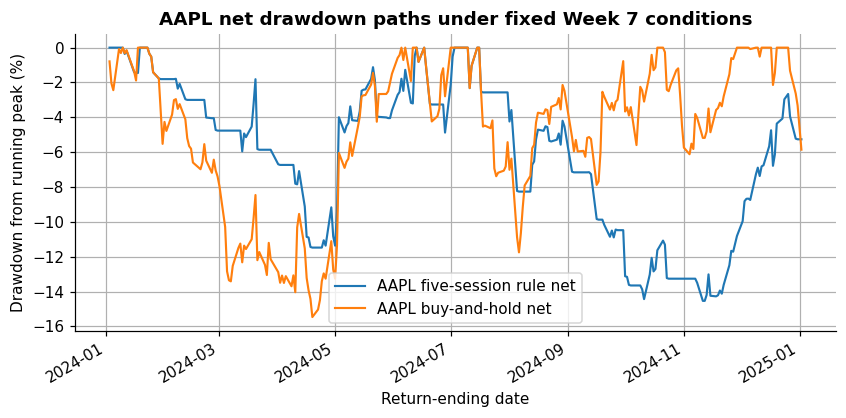

In [20]:
issue_9_candidate = drawdown_frame(candidate_ledger["net_return"])
issue_9_buy_hold = drawdown_frame(buy_hold_ledger["net_return"])
issue_9_real = pd.DataFrame(
    {
        "AAPL five-session rule net": issue_9_candidate["Drawdown (decimal)"],
        "AAPL buy-and-hold net": issue_9_buy_hold["Drawdown (decimal)"],
    }
)
issue_9_summary = pd.DataFrame(
    {
        "Maximum drawdown (percent)": issue_9_real.min() * 100,
        "Ending drawdown (percent)": issue_9_real.iloc[-1] * 100,
    }
)
display(issue_9_summary.style.format("{:.2f}").set_caption(
    "AAPL net drawdown summary; 2024-01-03 to 2025-01-02; stated teaching costs"
))

fig, ax = plt.subplots()
(issue_9_real * 100).plot(ax=ax, linewidth=1.4)
ax.set_title("AAPL net drawdown paths under fixed Week 7 conditions")
ax.set_xlabel("Return-ending date")
ax.set_ylabel("Drawdown from running peak (%)")
fig.tight_layout()
show_figure_with_alt_text(
    fig,
    "Line chart comparing percentage drawdowns for the AAPL five-session rule and buy-and-hold over 252 common daily intervals.",
)


### Interpret Code 2

The five-session rule's maximum net drawdown is -14.53%, compared with -15.46% for buy-and-hold. Their ending drawdowns are -5.26% and -5.86%, respectively. Final wealth and drawdown answer different questions, so the higher endpoint does not mechanically imply the shallower loss from a prior peak.

### Discussion questions

1. A calculation uses `wealth.cummax()` without comparing the running peak with initial wealth 1.00. Construct a first-period loss example, identify the omitted drawdown, and state the correction.
2. Two strategies end at the same wealth but follow different paths. State whether their maximum drawdowns must match and identify the table columns needed to verify the answer.


## Issue 10 — How do maximum drawdown, duration, and recovery differ?


Maximum drawdown depth is a percentage loss from a prior peak. Drawdown duration counts consecutive return observations below a peak. Recovery identifies whether and when wealth reaches the prior peak again. A path can have a shallow but long drawdown or a deep but brief one.

Week 7 counts duration in return observations. Calendar duration would require a separate date difference. If the sample ends underwater, the recovery date is reported as unavailable within the evaluated period rather than forecast.

### Connection to documented sources

The [GIPS Standards Handbook for Asset Owners](https://www.gipsstandards.org/standards/gips-standards-for-asset-owners/gips-standards-handbook-for-asset-owners/) lists drawdown as an ex post risk measure. The duration and recovery conventions below are explicitly defined by the code and must accompany the output.

### Controlled example

The first example extends Issue 9 with a fifth return that exceeds the prior peak.

### Before Code 1

Predict the maximum number of consecutive underwater observations and the recovery observation.


In [21]:
def drawdown_summary(return_series):
    frame = drawdown_frame(return_series)
    underwater = frame["Drawdown (decimal)"] < 0
    groups = (~underwater).cumsum()
    duration = underwater.groupby(groups).cumsum().astype(int)
    frame["Underwater"] = underwater
    frame["Current duration (observations)"] = duration
    trough_label = frame["Drawdown (decimal)"].idxmin()
    trough_position = frame.index.get_loc(trough_label)
    prior_peak = frame.loc[trough_label, "Running peak"]
    later_wealth = frame["Normalized wealth"].iloc[trough_position + 1:]
    recovered = later_wealth[later_wealth >= prior_peak]
    recovery_label = recovered.index[0] if len(recovered) else None
    summary = pd.Series(
        {
            "Maximum drawdown (decimal)": frame["Drawdown (decimal)"].min(),
            "Maximum drawdown label": str(trough_label),
            "Maximum duration (observations)": int(duration.max()),
            "Recovery label after maximum drawdown": (
                str(recovery_label) if recovery_label is not None else "Not recovered in sample"
            ),
        }
    )
    return frame, summary


controlled_issue_10_return = pd.Series(
    [0.10, -0.10, -0.05, 0.08, 0.10],
    index=["Observation 1", "Observation 2", "Observation 3", "Observation 4", "Observation 5"],
)
controlled_issue_10_frame, controlled_issue_10_summary = drawdown_summary(
    controlled_issue_10_return
)
display(controlled_issue_10_frame.style.format({
    "Return (decimal)": "{:.4f}",
    "Normalized wealth": "{:.6f}",
    "Running peak": "{:.6f}",
    "Drawdown (decimal)": "{:.4f}",
}).set_caption("Artificial drawdown depth, duration, and recovery"))
display(controlled_issue_10_summary.to_frame("Value"))
assert controlled_issue_10_summary["Maximum duration (observations)"] == 3


,Return (decimal),Normalized wealth,Running peak,Drawdown (decimal),Underwater,Current duration (observations)
Observation 1,0.1000,1.100000,1.100000,0.0000,False,0
Observation 2,-0.1000,0.990000,1.100000,-0.1000,True,1
Observation 3,-0.0500,0.940500,1.100000,-0.1450,True,2
Observation 4,0.0800,1.015740,1.100000,-0.0766,True,3
Observation 5,0.1000,1.117314,1.117314,0.0000,False,0


,Value
Maximum drawdown (decimal),-0.145
Maximum drawdown label,Observation 3
Maximum duration (observations),3
Recovery label after maximum drawdown,Observation 5


### Interpret Code 1

Maximum drawdown remains -14.50% at observation 3. Observations 2–4 are below the prior peak, so maximum duration is 3 observations. Wealth reaches 1.117314 at observation 5, above the prior 1.100000 peak, and the recovery label is observation 5.

### Source-grounded example

Code 2 reports depth, observation duration, and recovery status for each fixed noncash method.

### Before Code 2

Predict whether every method recovers from its maximum drawdown before 2025-01-02 and identify why duration must not be reported as a percentage.


In [22]:
issue_10_real_rows = []
for name, values in real_net_returns.drop(columns="Cash net").items():
    _, summary = drawdown_summary(values)
    issue_10_real_rows.append(
        {
            "Method": name,
            "Maximum drawdown (percent)": summary["Maximum drawdown (decimal)"] * 100,
            "Maximum duration (daily observations)": summary["Maximum duration (observations)"],
            "Recovery after maximum drawdown": summary["Recovery label after maximum drawdown"],
        }
    )
issue_10_real = pd.DataFrame(issue_10_real_rows)
display(issue_10_real.style.hide(axis="index").format({
    "Maximum drawdown (percent)": "{:.2f}",
}).set_caption(
    "AAPL net drawdown episodes; duration counted in daily return observations"
))


Method,Maximum drawdown (percent),Maximum duration (daily observations),Recovery after maximum drawdown
AAPL five-session rule net,-14.53,118,Not recovered in sample
AAPL twenty-session rule net,-13.94,118,Not recovered in sample
AAPL buy-and-hold net,-15.46,92,2024-06-05 00:00:00


### Interpret Code 2

The five-session rule's maximum duration is 118 daily observations and its maximum-drawdown trough is not recovered within the sample. Buy-and-hold's maximum duration is 92 observations and it recovers after its maximum-drawdown trough on 2024-06-05. Depth is measured in percent, duration in observations, and a missing recovery date means only that recovery did not occur before the sample ended.

### Discussion questions

1. Strategy A has a -12% maximum drawdown lasting 80 observations; Strategy B has a -20% drawdown lasting 15 observations. State which strategy is preferred under a depth limit of 15% and which under a duration limit of 30 observations.
2. A report states “drawdown duration = 14.5%.” Identify the category error and specify the two separate values and units that should replace it.


## Issue 11 — What does turnover add to the performance evidence?


Turnover measures trading intensity, not return or risk. Under Week 6's one-way convention,

$$
u_t=|w_t-w_{t-1}|,
\qquad
U=\sum_{t=1}^{T}u_t,
$$

where $w_t$ is the held portfolio fraction and the initial position is stated separately. Higher turnover increases deductions under a positive proportional cost, but turnover alone does not determine profitability because gross returns also differ.

### Connection to documented sources

The [pandas `Series.diff` documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html) documents the row difference used in position changes. Week 6 supplies the financial convention and cost identity carried into this lesson.

### Controlled example

The first example gives two strategies the same four asset returns but different held positions.

### Before Code 1

Predict which strategy has higher total one-way turnover and which pays more under a 4-basis-point rate.


In [23]:
controlled_issue_11_asset_return = pd.Series(
    [0.01, -0.01, 0.02, 0.00], index=pd.bdate_range("2026-02-02", periods=4)
)
controlled_issue_11_positions = {
    "Hold after entry": pd.Series([1.0, 1.0, 1.0, 1.0], index=controlled_issue_11_asset_return.index),
    "Trade each interval": pd.Series([1.0, 0.0, 1.0, 0.0], index=controlled_issue_11_asset_return.index),
}
controlled_issue_11_rows = []
for name, position in controlled_issue_11_positions.items():
    ledger = cost_ledger(position, controlled_issue_11_asset_return, TEACHING_TOTAL_ONE_WAY_BP)
    controlled_issue_11_rows.append(
        {
            "Method": name,
            "Total one-way turnover": ledger["one_way_turnover"].sum(),
            "Total cost deduction (basis points of return)": ledger["cost_return_units"].sum() * 10_000,
            "Final net wealth": ledger["net_wealth"].iloc[-1],
        }
    )
controlled_issue_11 = pd.DataFrame(controlled_issue_11_rows)
display(controlled_issue_11.style.hide(axis="index").format({
    "Final net wealth": "{:.6f}",
}).set_caption("Artificial turnover and cost comparison; 4 basis points one way"))


Method,Total one-way turnover,Total cost deduction (basis points of return),Final net wealth
Hold after entry,1.000000,4.000000,1.019494
Trade each interval,4.000000,16.000000,1.028565


### Interpret Code 1

`Hold after entry` has total one-way turnover 1.0 and a 4-basis-point cumulative deduction. `Trade each interval` has turnover 4.0 and a 16-basis-point deduction. Their final net wealth also reflects different held returns, so the 12-basis-point cost difference is not the only source of the endpoint difference.

### Source-grounded example

Code 2 displays total turnover, cost-bearing rows, and cost deductions for the three fixed AAPL methods.

### Before Code 2

Predict the turnover ordering and identify which method pays only one initial entry charge.


In [24]:
issue_11_ledgers = {
    "AAPL five-session rule": candidate_ledger,
    "AAPL twenty-session rule": slow_rule_ledger,
    "AAPL buy-and-hold": buy_hold_ledger,
}
issue_11_real = pd.DataFrame(
    {
        name: {
            "Total one-way turnover": ledger["one_way_turnover"].sum(),
            "Cost-bearing rows": int((ledger["one_way_turnover"] > 0).sum()),
            "Total cost deduction (percent of return units)": ledger["cost_return_units"].sum() * 100,
        }
        for name, ledger in issue_11_ledgers.items()
    }
).T
display(issue_11_real.style.format({
    "Total one-way turnover": "{:.1f}",
    "Cost-bearing rows": "{:.0f}",
    "Total cost deduction (percent of return units)": "{:.2f}",
}).set_caption(
    "AAPL trading intensity; 252 daily intervals; 4 basis points per unit of one-way turnover"
))


,Total one-way turnover,Cost-bearing rows,Total cost deduction (percent of return units)
AAPL five-session rule,52.0,52,2.08
AAPL twenty-session rule,23.0,23,0.92
AAPL buy-and-hold,1.0,1,0.04


### Interpret Code 2

Total one-way turnover is 52.0 for the five-session rule, 23.0 for the twenty-session rule, and 1.0 for buy-and-hold. Buy-and-hold has one cost-bearing row because the convention charges the initial move from cash and omits terminal liquidation. Turnover adds implementation evidence but does not rank risk-adjusted performance by itself.

### Discussion questions

1. A strategy with higher gross return also has twice the turnover of its benchmark. State the gross, cost, and net quantities required before deciding whether the extra trading improved the historical endpoint.
2. One report includes terminal liquidation and another omits it. Identify the turnover and cost rows affected and decide whether their total-turnover values are comparable without adjustment.


## Issue 12 — How can gross and net performance support different conclusions?


Gross return describes the strategy before the stated transaction-cost deduction. Net return describes the same positions and return intervals after that deduction. The comparison must hold the path fixed:

$$
r^{net}_t=r^{gross}_t-c u_t,
\qquad
W^{gross}_T=\prod_t(1+r^{gross}_t),
\qquad
W^{net}_T=\prod_t(1+r^{net}_t).
$$

Subtracting total cost from terminal wealth after compounding generally does not reproduce the dated net ledger. Costs must enter the return interval on which each trade is charged.

### Connection to documented sources

Perold's [The Implementation Shortfall: Paper versus Reality](https://doi.org/10.3905/jpm.1988.409150) establishes the importance of distinguishing paper decisions from implementation outcomes. The 4-basis-point values below remain teaching assumptions.

### Controlled example

The first example uses the `Trade each interval` position path from Issue 11.

### Before Code 1

Predict whether gross and net final wealth differ by exactly total cost deduction and explain why compounding may prevent that equality.


In [25]:
controlled_issue_12_ledger = cost_ledger(
    controlled_issue_11_positions["Trade each interval"],
    controlled_issue_11_asset_return,
    TEACHING_TOTAL_ONE_WAY_BP,
)
controlled_issue_12 = pd.Series(
    {
        "Gross final wealth": controlled_issue_12_ledger["gross_wealth"].iloc[-1],
        "Net final wealth": controlled_issue_12_ledger["net_wealth"].iloc[-1],
        "Difference in final wealth": (
            controlled_issue_12_ledger["gross_wealth"].iloc[-1]
            - controlled_issue_12_ledger["net_wealth"].iloc[-1]
        ),
        "Sum of dated cost deductions": controlled_issue_12_ledger["cost_return_units"].sum(),
        "Gross annualized return; P=4": compounded_annualized_return(
            controlled_issue_12_ledger["gross_return"], 4
        ),
        "Net annualized return; P=4": compounded_annualized_return(
            controlled_issue_12_ledger["net_return"], 4
        ),
    },
    name="Value",
)
display(controlled_issue_12.to_frame().style.format("{:.6f}"))
assert controlled_issue_12["Net final wealth"] < controlled_issue_12["Gross final wealth"]


,Value
Gross final wealth,1.030200
Net final wealth,1.028565
Difference in final wealth,0.001635
Sum of dated cost deductions,0.001600
Gross annualized return; P=4,0.030200
Net annualized return; P=4,0.028565


### Interpret Code 1

Gross final wealth is 1.030200, net final wealth is 1.028565, and their difference is 0.001635. The sum of dated return deductions is 0.001600, but compounding makes the terminal-wealth difference slightly greater than that simple sum. Gross and net annualized returns are 3.0200% and 2.8565%.

### Source-grounded example

Code 2 compares gross and net final wealth and annualized return for the same three AAPL position paths.

### Before Code 2

Predict which method has the largest gross-to-net annualized-return reduction and connect that prediction to total turnover.


Method,Total one-way turnover,Gross final wealth,Net final wealth,Gross annualized return (percent),Net annualized return (percent),Annualized-return reduction (percentage points)
AAPL five-session rule,52.0,1.058271,1.036463,5.8271,3.6463,2.1808
AAPL twenty-session rule,23.0,1.136155,1.125753,13.6155,12.5753,1.0402
AAPL buy-and-hold,1.0,1.313564,1.313035,31.3564,31.3035,0.0529


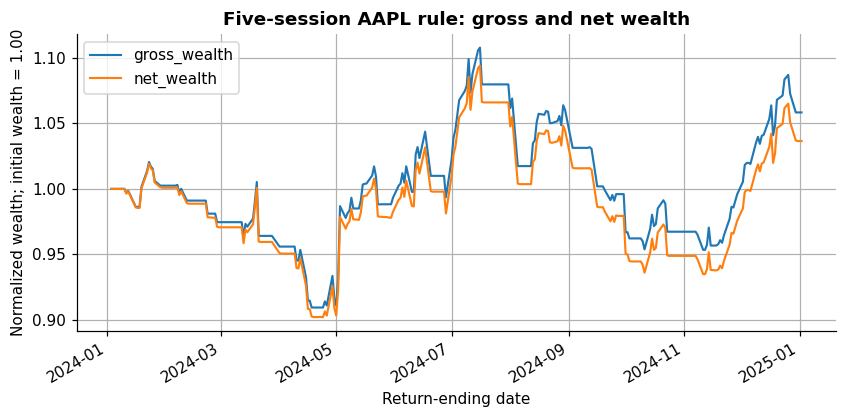

In [26]:
issue_12_real_rows = []
for name, ledger in issue_11_ledgers.items():
    gross_ann = compounded_annualized_return(ledger["gross_return"], PERIODS_PER_YEAR)
    net_ann = compounded_annualized_return(ledger["net_return"], PERIODS_PER_YEAR)
    issue_12_real_rows.append(
        {
            "Method": name,
            "Total one-way turnover": ledger["one_way_turnover"].sum(),
            "Gross final wealth": ledger["gross_wealth"].iloc[-1],
            "Net final wealth": ledger["net_wealth"].iloc[-1],
            "Gross annualized return (percent)": gross_ann * 100,
            "Net annualized return (percent)": net_ann * 100,
            "Annualized-return reduction (percentage points)": (gross_ann - net_ann) * 100,
        }
    )
issue_12_real = pd.DataFrame(issue_12_real_rows)
display(issue_12_real.style.hide(axis="index").format({
    "Total one-way turnover": "{:.1f}",
    "Gross final wealth": "{:.6f}",
    "Net final wealth": "{:.6f}",
    "Gross annualized return (percent)": "{:.4f}",
    "Net annualized return (percent)": "{:.4f}",
    "Annualized-return reduction (percentage points)": "{:.4f}",
}).set_caption(
    "AAPL gross and net performance; 252 daily intervals; 4 basis points one way"
))

fig, ax = plt.subplots()
candidate_ledger[["gross_wealth", "net_wealth"]].plot(ax=ax, linewidth=1.4)
ax.set_title("Five-session AAPL rule: gross and net wealth")
ax.set_xlabel("Return-ending date")
ax.set_ylabel("Normalized wealth; initial wealth = 1.00")
fig.tight_layout()
show_figure_with_alt_text(
    fig,
    "Line chart comparing gross and net normalized wealth for the five-session AAPL rule over 252 daily intervals.",
)


### Interpret Code 2

The five-session rule has the largest turnover at 52.0 and its annualized-return reduction is 2.1808 percentage points. The twenty-session rule's reduction is 1.0402 points and buy-and-hold's is 0.0529 points. The chart shows the dated accumulation of assumed costs; it is not evidence of actual AAPL fills.

### Discussion questions

1. A team reports a profitable gross endpoint and omits costs because no broker record is available. State which gross conclusion remains valid and which net conclusion must wait or be presented as a sensitivity assumption.
2. Two strategies pay the same total cost deduction but on different dates. Decide whether their gross-to-net terminal-wealth differences must match and identify the calculation needed to verify the answer.


## Issue 13 — What must be aligned before a benchmark comparison?


A benchmark comparison requires the same return-ending dates and compatible asset universe, return meaning, currency, frequency, cost status, initial holding, and terminal rule. Taking means from two separately filtered tables can compare different historical intervals even when both columns are labeled daily.

For candidate returns $r^C_t$ and benchmark returns $r^B_t$, the common comparison set is the intersection of return-ending dates after both definitions are fixed. Dropping a missing value is not neutral if it changes only one method's market exposure.

### Connection to documented sources

The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) repeatedly pairs strategy and benchmark statistics over corresponding periods. Week 7 applies that principle to a teaching backtest and does not claim GIPS compliance.

### Controlled example

The first example gives the candidate and benchmark one nonmatching date.

### Before Code 1

Predict the number of common dates and identify which two dates cannot enter a row-by-row comparison.


In [27]:
controlled_issue_13_candidate = pd.Series(
    [0.01, -0.01, 0.02],
    index=pd.to_datetime(["2026-03-02", "2026-03-03", "2026-03-05"]),
    name="Candidate net return",
)
controlled_issue_13_benchmark = pd.Series(
    [0.00, 0.01, -0.01],
    index=pd.to_datetime(["2026-03-02", "2026-03-04", "2026-03-05"]),
    name="Benchmark net return",
)
controlled_issue_13 = pd.concat(
    [controlled_issue_13_candidate, controlled_issue_13_benchmark], axis=1
)
controlled_issue_13["Both returns available"] = controlled_issue_13.notna().all(axis=1)
display(controlled_issue_13.style.format({
    "Candidate net return": "{:.4f}",
    "Benchmark net return": "{:.4f}",
}).set_caption("Artificial candidate and benchmark date alignment"))
print("Common return-ending dates:", int(controlled_issue_13["Both returns available"].sum()))
assert controlled_issue_13["Both returns available"].sum() == 2


,Candidate net return,Benchmark net return,Both returns available
2026-03-02 00:00:00,0.0100,0.0000,True
2026-03-03 00:00:00,-0.0100,nan,False
2026-03-04 00:00:00,nan,0.0100,False
2026-03-05 00:00:00,0.0200,-0.0100,True


Common return-ending dates: 2


### Interpret Code 1

Only March 2 and March 5 contain both returns, so there are 2 common dates. March 3 is candidate-only and March 4 is benchmark-only. Neither unmatched observation may enter a row-by-row active-return calculation without changing the financial question or reconstructing the missing interval.

### Source-grounded example

Code 2 audits dates and conventions for the four fixed Week 7 methods.

### Before Code 2

Predict whether the common-date intersection contains all 252 rows and identify the remaining return-convention limitation of buy-and-hold.


In [28]:
issue_13_real = pd.DataFrame(
    {
        "Method": real_net_returns.columns,
        "Available observations": real_net_returns.notna().sum().to_numpy(),
        "Matches common index": [real_net_returns[column].index.equals(source_eval.index) for column in real_net_returns],
        "Frequency": ["Daily"] * 4,
        "Cost status": ["Net of assumed 4 bp one-way cost"] * 3 + ["Assumed zero cash return"],
        "Return convention": ["AAPL price return; dividends excluded"] * 3 + ["Assumed cash return"],
    }
)
display(issue_13_real.style.hide(axis="index").set_caption(
    "Common-date and convention audit for Week 7 methods"
))
assert issue_13_real["Available observations"].eq(252).all()
assert issue_13_real["Matches common index"].all()


Method,Available observations,Matches common index,Frequency,Cost status,Return convention
AAPL five-session rule net,252,True,Daily,Net of assumed 4 bp one-way cost,AAPL price return; dividends excluded
AAPL twenty-session rule net,252,True,Daily,Net of assumed 4 bp one-way cost,AAPL price return; dividends excluded
AAPL buy-and-hold net,252,True,Daily,Net of assumed 4 bp one-way cost,AAPL price return; dividends excluded
Cash net,252,True,Daily,Assumed zero cash return,Assumed cash return


### Interpret Code 2

All four series match the same 252-date index. The three AAPL paths also share the daily Close-to-Close price-return convention and their stated cost rules. Buy-and-hold still excludes cash dividends, so it is a price-return benchmark rather than an AAPL total-return benchmark.

### Discussion questions

1. A candidate uses adjusted-close total returns while its benchmark uses unadjusted-close price returns. State why equal dates are insufficient and identify the return component that must be reconciled.
2. A benchmark starts ten days later than the candidate. Describe the fair common-period calculation and state which candidate-only claim can still be reported separately without entering the benchmark comparison.


## Issue 14 — What does benchmark-relative performance measure?


Active return is the dated difference between candidate and benchmark returns after alignment. Tracking error is the annualized sample standard deviation of active returns. The information ratio used here is annualized mean active return divided by tracking error:

$$
a_t=r^C_t-r^B_t,
\qquad
TE=s_a\sqrt{P},
\qquad
IR=\frac{\bar a}{s_a}\sqrt{P}.
$$

The information ratio is undefined when active-return volatility is zero. It answers a benchmark-relative question; it does not replace the candidate's absolute wealth, drawdown, or costs.

### Connection to documented sources

Sharpe's [The Sharpe Ratio](https://web.stanford.edu/~wfsharpe/art/sr/SR.htm) discusses differential returns relative to a benchmark. Week 7 states its tracking-error and annualization conventions explicitly.

### Controlled example

The first example uses four aligned candidate and benchmark net returns.

### Before Code 1

Predict the sign of mean active return and whether tracking error can be negative.


In [29]:
def benchmark_relative_metrics(candidate, benchmark, periods_per_year=252):
    aligned = pd.concat(
        [pd.Series(candidate, dtype=float), pd.Series(benchmark, dtype=float)],
        axis=1,
        join="inner",
    ).dropna()
    if len(aligned) < 2 or not np.isfinite(aligned.to_numpy()).all():
        raise ValueError("At least two aligned finite candidate and benchmark returns are required.")
    active = aligned.iloc[:, 0] - aligned.iloc[:, 1]
    tracking_error = active.std(ddof=1) * np.sqrt(periods_per_year)
    information_ratio = np.nan
    if not np.isclose(active.std(ddof=1), 0.0):
        information_ratio = active.mean() / active.std(ddof=1) * np.sqrt(periods_per_year)
    return pd.Series(
        {
            "Aligned observations": len(active),
            "Mean active return (decimal per period)": active.mean(),
            "Annualized tracking error (decimal)": tracking_error,
            "Information ratio": information_ratio,
        }
    )


controlled_issue_14_candidate = pd.Series([0.02, -0.01, 0.03, 0.00])
controlled_issue_14_benchmark = pd.Series([0.01, -0.02, 0.01, 0.01])
controlled_issue_14 = benchmark_relative_metrics(
    controlled_issue_14_candidate, controlled_issue_14_benchmark, 4
)
display(controlled_issue_14.to_frame("Value").style.format("{:.6f}"))
assert controlled_issue_14["Annualized tracking error (decimal)"] >= 0


,Value
Aligned observations,4.000000
Mean active return (decimal per period),0.007500
Annualized tracking error (decimal),0.025166
Information ratio,1.192079


### Interpret Code 1

Mean active return is 0.007500 per period, annualized tracking error is 0.025166, and the information ratio is 1.192079. Tracking error cannot be negative because it is a standard deviation. The positive ratio describes this four-observation benchmark-relative sample only.

### Source-grounded example

Code 2 compares the two AAPL timing rules with the fixed AAPL buy-and-hold net benchmark.

### Before Code 2

Predict the sign of each information ratio and state why both calculations must use the same benchmark dates and cost convention.


In [30]:
issue_14_real = pd.DataFrame(
    {
        "Five-session rule vs buy-and-hold": benchmark_relative_metrics(
            real_net_returns["AAPL five-session rule net"],
            real_net_returns["AAPL buy-and-hold net"],
            PERIODS_PER_YEAR,
        ),
        "Twenty-session rule vs buy-and-hold": benchmark_relative_metrics(
            real_net_returns["AAPL twenty-session rule net"],
            real_net_returns["AAPL buy-and-hold net"],
            PERIODS_PER_YEAR,
        ),
    }
).T
display(issue_14_real.style.format({
    "Aligned observations": "{:.0f}",
    "Mean active return (decimal per period)": "{:.6f}",
    "Annualized tracking error (decimal)": "{:.6f}",
    "Information ratio": "{:.4f}",
}).set_caption(
    "AAPL benchmark-relative net performance; 252 common daily intervals"
))


,Aligned observations,Mean active return (decimal per period),Annualized tracking error (decimal),Information ratio
Five-session rule vs buy-and-hold,252,-0.000984,0.152723,-1.6242
Twenty-session rule vs buy-and-hold,252,-0.000652,0.144799,-1.1352


### Interpret Code 2

The five-session rule has information ratio -1.6242 relative to buy-and-hold, while the twenty-session rule has -1.1352. Their annualized tracking errors are 0.152723 and 0.144799 in decimal units. These values describe deviations from buy-and-hold; they do not show absolute drawdown or future outperformance.

### Discussion questions

1. A candidate and benchmark have identical returns on every date. Calculate tracking error and decide how the information ratio should be reported.
2. A strategy has a positive information ratio but lower final wealth than cash. Explain how both statements can occur and identify the benchmark used by each conclusion.


## Issue 15 — Why can one metric not determine an overall ranking?


Annualized return, volatility, Sharpe ratio, Sortino ratio, maximum drawdown, drawdown duration, turnover, and final wealth describe different properties. A method can lead on one measure and trail on another. An overall ranking therefore requires a declared decision criterion rather than an unlabeled `best` column.

The common table below holds dates, return meaning, target, annualization, and costs fixed. It still does not choose how much return, drawdown, duration, or turnover matters to a particular investor.

### Connection to documented sources

The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) recommends presenting corresponding return and risk information for comparable periods. Week 7 additionally displays path and trading measures required by this course.

### Controlled example

The first example intentionally gives one artificial method higher final wealth and another shallower drawdown and lower turnover.

### Before Code 1

Predict whether the two methods receive the same ranking under `highest final wealth` and `maximum drawdown no deeper than -5%`.


In [31]:
controlled_issue_15_returns = pd.DataFrame(
    {
        "Method A": [0.08, -0.10, 0.09, 0.04],
        "Method B": [0.025, -0.02, 0.02, 0.015],
    }
)
controlled_issue_15_turnover = pd.Series({"Method A": 6.0, "Method B": 1.0})
controlled_issue_15_rows = []
for name, values in controlled_issue_15_returns.items():
    _, draw_summary = drawdown_summary(values)
    controlled_issue_15_rows.append(
        {
            "Method": name,
            "Final wealth": (1 + values).prod(),
            "Maximum drawdown (percent)": draw_summary["Maximum drawdown (decimal)"] * 100,
            "Total one-way turnover": controlled_issue_15_turnover[name],
        }
    )
controlled_issue_15 = pd.DataFrame(controlled_issue_15_rows)
display(controlled_issue_15.style.hide(axis="index").format({
    "Final wealth": "{:.6f}",
    "Maximum drawdown (percent)": "{:.2f}",
    "Total one-way turnover": "{:.1f}",
}).set_caption("Artificial methods with conflicting performance criteria"))


Method,Final wealth,Maximum drawdown (percent),Total one-way turnover
Method A,1.101859,-10.00,6.0
Method B,1.039959,-2.00,1.0


### Interpret Code 1

Method A has final wealth 1.101859 but maximum drawdown -10.00% and turnover 6.0. Method B has final wealth 1.039959, maximum drawdown -2.00%, and turnover 1.0. Highest wealth selects Method A, while a rule requiring maximum drawdown no deeper than -5% rejects Method A and admits Method B.

### Source-grounded example

Code 2 assembles the fixed Week 7 performance table. Undefined ratios remain `NaN` rather than being replaced by favorable values.

### Before Code 2

Predict whether one method leads every displayed metric and state the criterion you would use if maximum drawdown may not exceed 20%.


In [32]:
def complete_performance_row(values, turnover_value, periodic_target=0.0):
    values = pd.Series(values, dtype=float)
    _, draw_summary = drawdown_summary(values)
    return pd.Series(
        {
            "Annualized return (percent)": compounded_annualized_return(values, PERIODS_PER_YEAR) * 100,
            "Annualized volatility (percent)": annualized_volatility(values, PERIODS_PER_YEAR) * 100,
            "Sharpe ratio": annualized_sharpe(values, periodic_target, PERIODS_PER_YEAR),
            "Sortino ratio": annualized_sortino(values, periodic_target, PERIODS_PER_YEAR),
            "Maximum drawdown (percent)": draw_summary["Maximum drawdown (decimal)"] * 100,
            "Maximum duration (daily observations)": draw_summary["Maximum duration (observations)"],
            "Total one-way turnover": turnover_value,
            "Final wealth": (1 + values).prod(),
        }
    )


issue_15_turnover = {
    "AAPL five-session rule net": candidate_ledger["one_way_turnover"].sum(),
    "AAPL twenty-session rule net": slow_rule_ledger["one_way_turnover"].sum(),
    "AAPL buy-and-hold net": buy_hold_ledger["one_way_turnover"].sum(),
    "Cash net": 0.0,
}
issue_15_real = pd.DataFrame(
    {
        name: complete_performance_row(values, issue_15_turnover[name])
        for name, values in real_net_returns.items()
    }
).T
display(issue_15_real.style.format({
    "Annualized return (percent)": "{:.2f}",
    "Annualized volatility (percent)": "{:.2f}",
    "Sharpe ratio": "{:.3f}",
    "Sortino ratio": "{:.3f}",
    "Maximum drawdown (percent)": "{:.2f}",
    "Maximum duration (daily observations)": "{:.0f}",
    "Total one-way turnover": "{:.1f}",
    "Final wealth": "{:.4f}",
}).set_caption(
    "Week 7 common-condition performance table; 252 daily intervals; zero target; stated net costs"
))


,Annualized return (percent),Annualized volatility (percent),Sharpe ratio,Sortino ratio,Maximum drawdown (percent),Maximum duration (daily observations),Total one-way turnover,Final wealth
AAPL five-session rule net,3.65,16.65,0.298,0.418,-14.53,118,52.0,1.0365
AAPL twenty-session rule net,12.58,17.34,0.769,1.226,-13.94,118,23.0,1.1258
AAPL buy-and-hold net,31.30,22.55,1.320,2.053,-15.46,92,1.0,1.3130
Cash net,0.00,0.00,nan,nan,0.00,0,0.0,1.0000


### Interpret Code 2

No method leads every meaningful criterion. AAPL buy-and-hold has the highest annualized return at 31.30%, while the twenty-session rule has the shallowest noncash maximum drawdown at -13.94% and buy-and-hold has the lowest noncash turnover at 1.0. Cash has zero volatility and drawdown under its assumed path, but its Sharpe and Sortino ratios are undefined.

### Discussion questions

1. Apply a rule requiring maximum drawdown no deeper than -20%, then rank admitted methods by annualized net return. State every method admitted, the resulting ordering, and the conditions held fixed.
2. An investor instead minimizes turnover among methods with positive annualized net return. Use the displayed table to identify the selected method and explain why this answer need not match the highest-Sharpe choice.


## Issue 16 — How should market-period sensitivity be described?


A period comparison asks whether the measured result changes across boundaries chosen before interpreting the period-specific output. It is descriptive sensitivity evidence. Calling a period a `bull`, `bear`, or other market regime requires an independently defined classification available at the relevant time; a favorable or unfavorable return realized afterward is not itself a causal explanation.

Each period must retain the same strategy, cost, metric, target, and annualization conventions. A short-period annualized number must appear beside the actual period return and observation count.

### Connection to documented sources

Lo's [The Statistics of Sharpe Ratios](https://doi.org/10.2469/faj.v58.n4.2453) explains that the precision and interpretation of performance statistics depend on the observed process. Week 7 uses fixed calendar halves only as a descriptive sensitivity check.

### Controlled example

The first example supplies two prespecified four-observation periods with opposite candidate outcomes.

### Before Code 1

Predict whether the candidate has the same cumulative return sign in both periods and whether that difference alone proves a structural regime change.


In [33]:
controlled_issue_16 = pd.DataFrame(
    {
        "Candidate net": [0.03, 0.02, -0.01, 0.01, -0.03, -0.02, 0.01, -0.01],
        "Benchmark net": [0.01, 0.01, 0.00, 0.01, -0.01, -0.01, 0.00, 0.00],
        "Prespecified period": ["Period 1"] * 4 + ["Period 2"] * 4,
    }
)
controlled_issue_16_rows = []
for period, frame in controlled_issue_16.groupby("Prespecified period", sort=False):
    controlled_issue_16_rows.append(
        {
            "Period": period,
            "Observations": len(frame),
            "Candidate cumulative return (percent)": ((1 + frame["Candidate net"]).prod() - 1) * 100,
            "Benchmark cumulative return (percent)": ((1 + frame["Benchmark net"]).prod() - 1) * 100,
        }
    )
controlled_issue_16_summary = pd.DataFrame(controlled_issue_16_rows)
display(controlled_issue_16_summary.style.hide(axis="index").format({
    "Candidate cumulative return (percent)": "{:.2f}",
    "Benchmark cumulative return (percent)": "{:.2f}",
}).set_caption("Artificial prespecified-period comparison"))


Period,Observations,Candidate cumulative return (percent),Benchmark cumulative return (percent)
Period 1,4,5.05,3.03
Period 2,4,-4.95,-1.99


### Interpret Code 1

The candidate cumulative return is 5.05% in Period 1 and -4.95% in Period 2, while the benchmark also changes from 3.03% to -1.99%. The sign reversal shows period sensitivity in these eight artificial observations. It does not identify the economic cause or prove a persistent regime.

### Source-grounded example

Code 2 fixes two calendar periods before calculation: return-ending dates through 2024-06-28 and dates from 2024-07-01 onward.

### Before Code 2

Predict whether the five-session rule has the same annualized-return and Sharpe signs in both periods and identify which actual, nonannualized result must remain visible.


In [34]:
issue_16_periods = {
    "2024 first calendar half": (real_net_returns.index <= pd.Timestamp("2024-06-28")),
    "2024 second calendar half plus 2025-01-02": (real_net_returns.index >= pd.Timestamp("2024-07-01")),
}
issue_16_real_rows = []
for label, mask in issue_16_periods.items():
    candidate_values = real_net_returns.loc[mask, "AAPL five-session rule net"]
    benchmark_values = real_net_returns.loc[mask, "AAPL buy-and-hold net"]
    issue_16_real_rows.append(
        {
            "Prespecified period": label,
            "Observations": len(candidate_values),
            "Candidate cumulative net return (percent)": ((1 + candidate_values).prod() - 1) * 100,
            "Candidate annualized net return (percent)": compounded_annualized_return(candidate_values, PERIODS_PER_YEAR) * 100,
            "Candidate Sharpe; zero target": annualized_sharpe(candidate_values, 0.0, PERIODS_PER_YEAR),
            "Buy-and-hold cumulative net return (percent)": ((1 + benchmark_values).prod() - 1) * 100,
        }
    )
issue_16_real = pd.DataFrame(issue_16_real_rows)
display(issue_16_real.style.hide(axis="index").format({
    "Candidate cumulative net return (percent)": "{:.2f}",
    "Candidate annualized net return (percent)": "{:.2f}",
    "Candidate Sharpe; zero target": "{:.3f}",
    "Buy-and-hold cumulative net return (percent)": "{:.2f}",
}).set_caption(
    "AAPL calendar-period sensitivity; strategy, costs, target, and metrics held fixed"
))


Prespecified period,Observations,Candidate cumulative net return (percent),Candidate annualized net return (percent),Candidate Sharpe; zero target,Buy-and-hold cumulative net return (percent)
2024 first calendar half,123,-1.87,-3.80,-0.149,13.41
2024 second calendar half plus 2025-01-02,129,5.62,11.28,0.726,15.78


### Interpret Code 2

The first period has 123 observations, candidate cumulative net return -1.87%, annualized return -3.80%, and Sharpe -0.149. The second has 129 observations with cumulative net return 5.62%, annualized return 11.28%, and Sharpe 0.726. These are descriptive calendar-period differences, not evidence of a detected or causal market regime.

### Discussion questions

1. A team chooses its period boundary after locating the strategy's largest loss. Decide whether the comparison remains prespecified and state how the boundary-selection process must be disclosed.
2. The first period has 123 observations and the second 129. Identify the actual cumulative and annualized quantities needed to prevent the annualized figures from hiding the unequal sample lengths.


## Issue 17 — Why does serial dependence matter for uncertainty?


Serial dependence means the order of returns contains information about nearby observations. Two series can have the same mean and standard deviation but different lag-one correlation because gains and losses cluster differently. Treating every return as an independent draw can then misrepresent uncertainty.

The sample lag-one autocorrelation is a descriptive check, not proof that a process is stationary or that one resampling method is correct. A short series also produces a noisy estimate.

### Connection to documented sources

Lo's [The Statistics of Sharpe Ratios](https://doi.org/10.2469/faj.v58.n4.2453) shows why serial correlation affects Sharpe-ratio statistics. Politis and Romano's [circular block-resampling report](https://statistics.stanford.edu/technical-reports/circular-block-resampling-procedure-stationary-data) provides the basis for preserving short contiguous blocks in Issue 18.

### Controlled example

The first example gives clustered and alternating series the same multiset of returns.

### Before Code 1

Predict whether their means and standard deviations match and which series has the larger lag-one autocorrelation.


In [35]:
controlled_issue_17 = pd.DataFrame(
    {
        "Clustered order": [0.015, 0.012, 0.009, -0.006, -0.008, -0.010] * 2,
        "Alternating order": [0.015, -0.006, 0.012, -0.008, 0.009, -0.010] * 2,
    }
)
controlled_issue_17_summary = pd.DataFrame(
    {
        "Mean return": controlled_issue_17.mean(),
        "Sample volatility": controlled_issue_17.std(ddof=1),
        "Lag-one autocorrelation": controlled_issue_17.apply(lambda values: values.autocorr(lag=1)),
    }
)
display(controlled_issue_17_summary.style.format("{:.4f}").set_caption(
    "Artificial series with the same return counts but different order"
))
assert np.isclose(
    controlled_issue_17_summary.loc["Clustered order", "Sample volatility"],
    controlled_issue_17_summary.loc["Alternating order", "Sample volatility"],
)


,Mean return,Sample volatility,Lag-one autocorrelation
Clustered order,0.0020,0.0107,0.5052
Alternating order,0.0020,0.0107,-0.9414


### Interpret Code 1

Both series have mean 0.0020 and sample volatility 0.0107. The clustered order has lag-one autocorrelation 0.5052, while the alternating order has -0.9414. Reordering leaves the marginal mean and volatility unchanged but changes local dependence.

### Source-grounded example

Code 2 calculates lag-one and lag-five autocorrelations for the candidate and buy-and-hold net returns.

### Before Code 2

Predict whether either lag-one value is exactly zero and state why a nonzero sample value does not prove stable dependence.


In [36]:
issue_17_real = pd.DataFrame(
    {
        "Lag-one autocorrelation": real_net_returns[
            ["AAPL five-session rule net", "AAPL buy-and-hold net"]
        ].apply(lambda values: values.autocorr(lag=1)),
        "Lag-five autocorrelation": real_net_returns[
            ["AAPL five-session rule net", "AAPL buy-and-hold net"]
        ].apply(lambda values: values.autocorr(lag=5)),
        "Observations": real_net_returns[
            ["AAPL five-session rule net", "AAPL buy-and-hold net"]
        ].notna().sum(),
    }
)
display(issue_17_real.style.format({
    "Lag-one autocorrelation": "{:.4f}",
    "Lag-five autocorrelation": "{:.4f}",
    "Observations": "{:.0f}",
}).set_caption("Sample autocorrelations of fixed AAPL net-return paths"))


,Lag-one autocorrelation,Lag-five autocorrelation,Observations
AAPL five-session rule net,0.0073,-0.0782,252
AAPL buy-and-hold net,0.0620,-0.0990,252


### Interpret Code 2

The five-session rule has lag-one autocorrelation 0.0073 and lag-five autocorrelation -0.0782. Buy-and-hold has 0.0620 and -0.0990. These 252-observation estimates motivate a dependence-sensitive uncertainty check but do not establish stationarity or a correct block length.

### Discussion questions

1. Two return series have equal mean and volatility but lag-one correlations 0.60 and -0.60. State why independent row resampling discards the distinction and which part of a block method attempts to retain it.
2. A strategy's sample lag-one autocorrelation is 0.08. Decide whether that value proves serial dependence and identify at least two additional checks or assumptions needed for inference.


## Issue 18 — What does a circular block-bootstrap interval show?


A circular block bootstrap selects a starting position, takes a contiguous block, wraps past the end when necessary, and repeats until one resampled series has the original length. The procedure preserves some neighboring order within blocks. It does not prove that the chosen block length represents the true dependence structure.

For each resampled series, Week 7 recalculates the zero-target Sharpe ratio. The displayed 2.5%, 50%, and 97.5% sample quantiles describe the bootstrap distribution under the recorded return series, circular-block procedure, block length, repetition count, and random seed. They are not prediction limits for future performance.

### Connection to documented sources

Politis and Romano's [A Circular Block-Resampling Procedure for Stationary Data](https://statistics.stanford.edu/technical-reports/circular-block-resampling-procedure-stationary-data) supplies the established method. Lo's [Sharpe-ratio paper](https://doi.org/10.2469/faj.v58.n4.2453) motivates attention to dependence in uncertainty analysis.

### Controlled example

The first example resamples the clustered artificial series from Issue 17 with block lengths 1 and 4, 1,000 repetitions, and seed 77.

### Before Code 1

Predict whether the two intervals are identical and explain which single setting changes.


In [37]:
def circular_block_bootstrap_sharpe(
    return_series,
    block_length=5,
    repetitions=1000,
    seed=77,
    periodic_target=0.0,
    periods_per_year=252,
):
    values = pd.Series(return_series, dtype=float).dropna().to_numpy()
    if len(values) < 2 or not np.isfinite(values).all():
        raise ValueError("At least two finite returns are required.")
    if not 1 <= block_length <= len(values):
        raise ValueError("Block length must be between 1 and the sample length.")
    if repetitions < 1:
        raise ValueError("Repetitions must be positive.")
    rng = np.random.default_rng(seed)
    estimates = []
    n = len(values)
    for _ in range(repetitions):
        pieces = []
        collected = 0
        while collected < n:
            start = int(rng.integers(0, n))
            indexes = (start + np.arange(block_length)) % n
            piece = values[indexes]
            pieces.append(piece)
            collected += len(piece)
        sample = np.concatenate(pieces)[:n]
        estimates.append(
            annualized_sharpe(sample, periodic_target, periods_per_year)
        )
    estimates = np.asarray(estimates, dtype=float)
    return estimates


controlled_issue_18_rows = []
for block_length in [1, 4]:
    estimates = circular_block_bootstrap_sharpe(
        controlled_issue_17["Clustered order"],
        block_length=block_length,
        repetitions=1000,
        seed=77,
        periods_per_year=12,
    )
    controlled_issue_18_rows.append(
        {
            "Block length": block_length,
            "Repetitions": len(estimates),
            "Finite Sharpe estimates": int(np.isfinite(estimates).sum()),
            "2.5% Sharpe quantile": np.nanquantile(estimates, 0.025),
            "Median Sharpe": np.nanquantile(estimates, 0.50),
            "97.5% Sharpe quantile": np.nanquantile(estimates, 0.975),
        }
    )
controlled_issue_18 = pd.DataFrame(controlled_issue_18_rows)
display(controlled_issue_18.style.hide(axis="index").format({
    "2.5% Sharpe quantile": "{:.3f}",
    "Median Sharpe": "{:.3f}",
    "97.5% Sharpe quantile": "{:.3f}",
}).set_caption("Circular block-bootstrap sensitivity for clustered artificial returns; seed 77"))


Block length,Repetitions,Finite Sharpe estimates,2.5% Sharpe quantile,Median Sharpe,97.5% Sharpe quantile
1,1000,1000,-1.537,0.647,2.906
4,1000,1000,-0.980,0.650,2.451


### Interpret Code 1

With block length 1, all 1,000 Sharpe estimates are finite and the displayed quantiles are -1.537, 0.647, and 2.906. With block length 4, all 1,000 estimates are finite and the quantiles are -0.980, 0.650, and 2.451. Only block length changes; the difference is sensitivity evidence, not proof that either interval has correct coverage.

### Source-grounded example

Code 2 uses the fixed candidate net returns with block lengths 1, 5, and 20. Repetitions, seed, target, annualization factor, and return series remain fixed.

### Before Code 2

Predict whether all three interval endpoints move monotonically with block length and identify why no monotonic pattern is required.


Block length (daily observations),Repetitions,Finite Sharpe estimates,2.5% Sharpe quantile,Median Sharpe,97.5% Sharpe quantile
1,1000,1000,-1.675,0.306,2.216
5,1000,1000,-1.634,0.297,2.106
20,1000,1000,-1.567,0.251,2.359


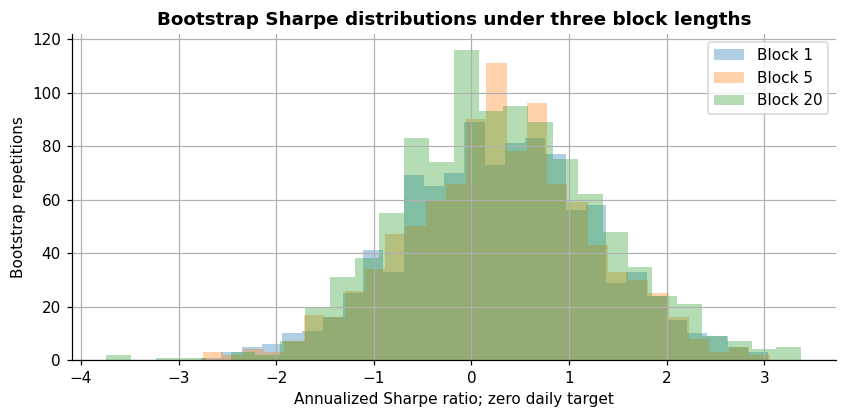

In [38]:
issue_18_real_rows = []
issue_18_real_estimates = {}
for block_length in [1, 5, 20]:
    estimates = circular_block_bootstrap_sharpe(
        candidate_ledger["net_return"],
        block_length=block_length,
        repetitions=1000,
        seed=77,
        periodic_target=0.0,
        periods_per_year=PERIODS_PER_YEAR,
    )
    issue_18_real_estimates[block_length] = estimates
    issue_18_real_rows.append(
        {
            "Block length (daily observations)": block_length,
            "Repetitions": len(estimates),
            "Finite Sharpe estimates": int(np.isfinite(estimates).sum()),
            "2.5% Sharpe quantile": np.nanquantile(estimates, 0.025),
            "Median Sharpe": np.nanquantile(estimates, 0.50),
            "97.5% Sharpe quantile": np.nanquantile(estimates, 0.975),
        }
    )
issue_18_real = pd.DataFrame(issue_18_real_rows)
display(issue_18_real.style.hide(axis="index").format({
    "2.5% Sharpe quantile": "{:.3f}",
    "Median Sharpe": "{:.3f}",
    "97.5% Sharpe quantile": "{:.3f}",
}).set_caption(
    "Circular block-bootstrap Sharpe sensitivity; five-session AAPL rule; 1,000 repetitions; seed 77"
))

fig, ax = plt.subplots()
for block_length, estimates in issue_18_real_estimates.items():
    ax.hist(
        estimates[np.isfinite(estimates)],
        bins=28,
        alpha=0.35,
        label=f"Block {block_length}",
    )
ax.set_title("Bootstrap Sharpe distributions under three block lengths")
ax.set_xlabel("Annualized Sharpe ratio; zero daily target")
ax.set_ylabel("Bootstrap repetitions")
ax.legend()
fig.tight_layout()
show_figure_with_alt_text(
    fig,
    "Overlaid histograms of 1,000 bootstrap Sharpe ratios for block lengths 1, 5, and 20 using the same five-session AAPL net-return series.",
)


### Interpret Code 2

All three settings produce 1,000 finite Sharpe estimates. For block lengths 1, 5, and 20, the 2.5% quantiles are -1.675, -1.634, and -1.567; the medians are 0.306, 0.297, and 0.251; and the 97.5% quantiles are 2.216, 2.106, and 2.359. The endpoints do not move monotonically because each block length changes the dependence retained by the resampling scheme. None is a forecast interval for future AAPL performance.

### Discussion questions

1. Hold the return series, 1,000 repetitions, seed 77, target, and annualization factor fixed. Choose two block lengths from the table, calculate the change in interval width, and state the limited sensitivity conclusion supported.
2. A report presents only the narrowest bootstrap interval after trying ten block lengths. Identify the additional selection problem and state which attempted settings must be disclosed.


## Issue 19 — How can repeated strategy selection create an optimistic result?


When many alternatives are evaluated and only the highest selection-period result is reported, the chosen result reflects both the underlying process and favorable sample variation. The number of tried strategies, thresholds, features, windows, cost settings, and period definitions is therefore part of the evidence.

The examples below keep a selection period separate from a later evaluation period. They illustrate selection risk; they do not calculate the probability of backtest overfitting and do not prove that every selected strategy must deteriorate.

### Connection to documented sources

White's [A Reality Check for Data Snooping](https://doi.org/10.1111/1468-0262.00152) addresses testing after specification search. Bailey et al.'s [The Probability of Backtest Overfitting](https://www.davidhbailey.com/dhbpapers/backtest-prob.pdf) formalizes a more extensive strategy-selection analysis than this teaching demonstration.

### Controlled example

The first example creates 30 random long-or-cash rules with no designed predictive relation to a separate zero-mean artificial asset return. It selects the highest first-half net Sharpe and reports that same rule in the second half.

### Before Code 1

Predict whether the selected first-half Sharpe exceeds the median of all 30 first-half values and state why the later Sharpe may be smaller.


In [39]:
selection_dates = pd.bdate_range("2024-01-02", periods=520)
selection_asset_return = pd.Series(
    np.random.default_rng(6).normal(0.0, 0.012, len(selection_dates)),
    index=selection_dates,
)
trial_rng = np.random.default_rng(88)
trial_positions = pd.DataFrame(
    trial_rng.integers(0, 2, size=(len(selection_dates), 30)),
    index=selection_dates,
    columns=[f"trial_{i:02d}" for i in range(30)],
).shift(1).fillna(0.0)
trial_turnover = trial_positions.diff().abs()
trial_turnover.iloc[0] = trial_positions.iloc[0].abs()
trial_returns = (
    trial_positions.mul(selection_asset_return, axis=0)
    - trial_turnover * TEACHING_TOTAL_ONE_WAY_BP / 10_000
)
selection_split = len(trial_returns) // 2
selection_values = trial_returns.iloc[:selection_split].apply(
    annualized_sharpe, periodic_target=0.0, periods_per_year=PERIODS_PER_YEAR
)
selected_trial = selection_values.idxmax()
later_value = annualized_sharpe(
    trial_returns[selected_trial].iloc[selection_split:], 0.0, PERIODS_PER_YEAR
)
controlled_issue_19 = pd.Series(
    {
        "Alternatives tried": trial_returns.shape[1],
        "Selected trial": selected_trial,
        "Selected first-half Sharpe": selection_values[selected_trial],
        "Median first-half Sharpe": selection_values.median(),
        "Same trial later-period Sharpe": later_value,
    },
    name="Value",
)
display(controlled_issue_19.to_frame())
assert selection_values[selected_trial] >= selection_values.median()


,Value
Alternatives tried,30
Selected trial,trial_28
Selected first-half Sharpe,1.870871
Median first-half Sharpe,0.142824
Same trial later-period Sharpe,0.249048


### Interpret Code 1

The procedure tries 30 alternatives and selects `trial_28`. Its first-half Sharpe is 1.8709, compared with the 30-trial median 0.1428; the same rule's later-period Sharpe is 0.2490. This one reproducible realization illustrates selection optimism but does not estimate its general probability.

### Source-grounded example

Code 2 applies ten disclosed momentum lookbacks to the same source-derived AAPL returns and 4-basis-point cost. It selects on the first 126 observations and evaluates the chosen lookback only on the later 126 observations.

### Before Code 2

Predict whether the selected lookback remains the highest-Sharpe lookback later and state why either outcome would remain only one historical example.


In [40]:
issue_19_lookbacks = [2, 3, 5, 8, 10, 15, 20, 30, 40, 60]
issue_19_variants = {}
for lookback in issue_19_lookbacks:
    momentum = aapl_frame["Close"] / aapl_frame["Close"].shift(lookback) - 1
    signal = pd.Series(
        np.where(momentum.isna(), np.nan, (momentum > 0).astype(float)),
        index=aapl_frame.index,
    )
    position = signal.shift(1).fillna(0.0).reindex(source_eval.index)
    ledger = cost_ledger(
        position,
        source_eval["asset_return"],
        TEACHING_TOTAL_ONE_WAY_BP,
    )
    issue_19_variants[lookback] = ledger["net_return"]

issue_19_returns = pd.DataFrame(issue_19_variants)
issue_19_split = len(issue_19_returns) // 2
issue_19_selection = issue_19_returns.iloc[:issue_19_split].apply(
    annualized_sharpe, periodic_target=0.0, periods_per_year=PERIODS_PER_YEAR
)
issue_19_later = issue_19_returns.iloc[issue_19_split:].apply(
    annualized_sharpe, periodic_target=0.0, periods_per_year=PERIODS_PER_YEAR
)
issue_19_selected_lookback = int(issue_19_selection.idxmax())
issue_19_real = pd.Series(
    {
        "Lookbacks tried": len(issue_19_lookbacks),
        "Selection observations": issue_19_split,
        "Later evaluation observations": len(issue_19_returns) - issue_19_split,
        "Selected lookback (sessions)": issue_19_selected_lookback,
        "Selected first-half Sharpe": issue_19_selection.loc[issue_19_selected_lookback],
        "Same lookback later-period Sharpe": issue_19_later.loc[issue_19_selected_lookback],
        "Later-period rank of selected lookback (1 = highest)": issue_19_later.rank(ascending=False, method="min").loc[issue_19_selected_lookback],
    },
    name="Value",
)
display(issue_19_real.to_frame())


,Value
Lookbacks tried,10.000000
Selection observations,126.000000
Later evaluation observations,126.000000
Selected lookback (sessions),40.000000
Selected first-half Sharpe,2.967956
Same lookback later-period Sharpe,0.704719
Later-period rank of selected lookback (1 = highest),4.000000


### Interpret Code 2

Ten disclosed AAPL lookbacks are tried. The first 126 observations select a 40-session lookback with Sharpe 2.9680. On the later 126 observations, that same rule has Sharpe 0.7047 and rank 4 of 10. This is one source-grounded historical demonstration under assumed costs, not an estimate of overfitting probability or a claim about future results.

### Discussion questions

1. A team reports only the best of 80 model, feature, and threshold combinations. State the minimum selection record required and identify why the reported Sharpe cannot be interpreted like a single prespecified test.
2. Suppose the selected strategy also ranks first in the later period. Decide which concern is reduced and which claims about future performance or general absence of overfitting remain unsupported.


## Issue 20 — What conclusion survives a complete backtest audit?


A backtest audit examines the evidence needed for a particular claim. Use `pass` when the required record is present and consistent, `fail` when it contradicts the stated method or claim, and `unclear` when necessary information is absent. Every `fail` or `unclear` row must state the consequence and next check.

An audit does not turn assumptions into observations or guarantee future performance. It identifies which historical calculation can be reproduced and which broader claim must wait.

### Connection to documented sources

White's [data-snooping paper](https://doi.org/10.1111/1468-0262.00152), Bailey et al.'s [backtest-overfitting paper](https://www.davidhbailey.com/dhbpapers/backtest-prob.pdf), and the [Report 1 instructions](../10/week10_main.md) support recording tried alternatives, separating evaluation evidence, and limiting the conclusion.

### Controlled example

The first example audits a stated scenario: signals are shifted before returns, all position changes use the same assumed cost, benchmark dates match, but no quote or fill record exists and the team selected the best of unreported variants.

### Before Code 1

Predict which rows must be `unclear` or `fail` and state which conclusion remains permissible.


In [41]:
controlled_issue_20 = pd.DataFrame(
    [
        ("Signal precedes held return", "pass", "Shifted signal and dated position are shown", "Retain the dated ledger"),
        ("Cost identity", "pass", "Every position change receives the same assumed rate", "Retain gross, turnover, cost, and net columns"),
        ("Measured execution cost", "unclear", "No quote, order, or fill record exists", "Keep cost labeled assumed or obtain execution evidence"),
        ("Common benchmark dates", "pass", "Candidate and benchmark indexes match", "Retain the common-date check"),
        ("Tried alternatives", "fail", "Only the selected result is reported", "Disclose every tried specification and selection rule"),
        ("Future-performance claim", "fail", "Only historical teaching evidence is available", "Restrict the claim to the tested sample"),
    ],
    columns=["Audit item", "Status", "Evidence or problem", "Required action"],
)
display(controlled_issue_20.style.hide(axis="index").set_caption("Artificial backtest audit"))
print(controlled_issue_20["Status"].value_counts().sort_index())
assert set(controlled_issue_20["Status"]) == {"pass", "fail", "unclear"}


Audit item,Status,Evidence or problem,Required action
Signal precedes held return,pass,Shifted signal and dated position are shown,Retain the dated ledger
Cost identity,pass,Every position change receives the same assumed rate,"Retain gross, turnover, cost, and net columns"
Measured execution cost,unclear,"No quote, order, or fill record exists",Keep cost labeled assumed or obtain execution evidence
Common benchmark dates,pass,Candidate and benchmark indexes match,Retain the common-date check
Tried alternatives,fail,Only the selected result is reported,Disclose every tried specification and selection rule
Future-performance claim,fail,Only historical teaching evidence is available,Restrict the claim to the tested sample


Status
fail       2
pass       3
unclear    1
Name: count, dtype: int64


### Interpret Code 1

The audit contains 3 `pass`, 2 `fail`, and 1 `unclear` judgments. It permits reconstruction of historical net returns under an assumed cost. It does not permit a measured-execution-cost claim, a selection-free performance claim, or a future-performance claim.

### Source-grounded example

Code 2 audits the complete fixed Week 7 teaching comparison and links each limitation to a concrete next check.

### Before Code 2

Predict which rows cannot receive `pass` despite successful code execution and state the narrow historical conclusion the evidence supports.


In [42]:
issue_20_real = pd.DataFrame(
    [
        ("Source request and return dates", "pass", "AAPL/MSFT request and 252 common dates are displayed", "Retain request and date summary"),
        ("Signal, position, and return timing", "pass", "Signals are shifted one row before held returns", "Retain dated position logic"),
        ("Gross-to-net identity", "pass", "Gross, turnover, assumed cost, and net returns reconcile", "Retain ledger checks"),
        ("Benchmark alignment", "pass", "All methods use the common 252-date index", "Retain convention audit"),
        ("Measured transaction costs", "unclear", "Daily data contain no orders, quotes, or fills", "Obtain execution evidence or retain sensitivity label"),
        ("Return meaning and distributions", "pass", "The notebook labels all AAPL paths as price returns with dividends excluded", "Do not describe the result as total return"),
        ("Frozen final test", "fail", "The teaching period is repeatedly displayed", "Use a separately protected period for a confirmatory claim"),
        ("Tried alternatives", "unclear", "Ten notebook lookbacks are shown, but work outside the notebook is unknown", "Disclose every additional model, feature, threshold, and period tried"),
        ("Sampling uncertainty", "pass", "Block method, lengths, repetitions, and seed are shown", "Report block-length sensitivity and assumptions"),
        ("Future-performance claim", "fail", "Historical and resampled evidence cannot guarantee future returns", "Restrict conclusions to tested conditions"),
    ],
    columns=["Audit item", "Status", "Evidence or problem", "Required action"],
)
display(issue_20_real.style.hide(axis="index").set_caption(
    "Audit of the fixed Week 7 AAPL teaching comparison"
))
issue_20_counts = issue_20_real["Status"].value_counts().reindex(
    ["pass", "unclear", "fail"], fill_value=0
)
display(issue_20_counts.rename("Rows").to_frame())
assert issue_20_counts.sum() == len(issue_20_real)


Audit item,Status,Evidence or problem,Required action
Source request and return dates,pass,AAPL/MSFT request and 252 common dates are displayed,Retain request and date summary
"Signal, position, and return timing",pass,Signals are shifted one row before held returns,Retain dated position logic
Gross-to-net identity,pass,"Gross, turnover, assumed cost, and net returns reconcile",Retain ledger checks
Benchmark alignment,pass,All methods use the common 252-date index,Retain convention audit
Measured transaction costs,unclear,"Daily data contain no orders, quotes, or fills",Obtain execution evidence or retain sensitivity label
Return meaning and distributions,pass,The notebook labels all AAPL paths as price returns with dividends excluded,Do not describe the result as total return
Frozen final test,fail,The teaching period is repeatedly displayed,Use a separately protected period for a confirmatory claim
Tried alternatives,unclear,"Ten notebook lookbacks are shown, but work outside the notebook is unknown","Disclose every additional model, feature, threshold, and period tried"
Sampling uncertainty,pass,"Block method, lengths, repetitions, and seed are shown",Report block-length sensitivity and assumptions
Future-performance claim,fail,Historical and resampled evidence cannot guarantee future returns,Restrict conclusions to tested conditions


,Rows
Status,
pass,6
unclear,2
fail,2


### Interpret Code 2

The Week 7 audit contains 6 `pass`, 2 `unclear`, and 2 `fail` rows. It supports a reproducible comparison of source-derived historical AAPL price-return paths under declared teaching positions, targets, costs, benchmarks, and uncertainty settings. It does not establish measured trading costs, AAPL total return, an unused final test, freedom from all undisclosed experimentation, or future performance.

### Discussion questions

1. Select one `unclear` and one `fail` row. For each, state the exact missing or contradictory evidence, the next check, and the claim that must wait.
2. Write one sentence that reports the five-session rule's historical evidence without using `better`, `robust`, or `profitable` alone. The sentence must name a metric, comparison baseline, period, cost status, and one limitation.


# Independent practice issues

The first three exercises isolate performance calculation, benchmark alignment, and uncertainty sensitivity. Case 4 combines the complete Week 7 comparison and audit. Starter cells display all required inputs but do not calculate the requested answers. Complete only the submissions designated by the instructor.

## Practice issue 1 — Reconcile return, risk, and drawdown measures

Use the six supplied artificial daily net returns. Calculate arithmetic mean daily return, final wealth, cumulative return, annualized return, annualized volatility, zero-target Sharpe, zero-target Sortino under Week 7's all-observation downside denominator, maximum drawdown, and maximum drawdown duration. Use $P=6$ so the six observations form one artificial annualization period.

Before calculating, predict the sign of cumulative return and the deepest drawdown date. Your completed output must keep units and conventions beside every value and verify the wealth and drawdown rows rather than calling the path `good` or `bad`.

### Discussion questions

1. Identify one pair of metrics that answers different questions despite using the same returns, and state the decision each metric informs.
2. Reorder the six returns without changing their values. State which requested outputs must remain equal and which path measures may change.


In [43]:
practice_1_returns = pd.Series(
    [0.025, -0.015, 0.010, -0.030, 0.020, 0.005],
    index=pd.bdate_range("2026-09-01", periods=6),
    name="Artificial daily net return (decimal)",
)
display(practice_1_returns.to_frame().style.format("{:.4f}").set_caption(
    "Practice 1 input; six artificial daily net returns; use P=6 and zero target"
))
print("Student task: calculate the complete metric and drawdown record; no answer is supplied.")


,Artificial daily net return (decimal)
2026-09-01 00:00:00,0.0250
2026-09-02 00:00:00,-0.0150
2026-09-03 00:00:00,0.0100
2026-09-04 00:00:00,-0.0300
2026-09-07 00:00:00,0.0200
2026-09-08 00:00:00,0.0050


Student task: calculate the complete metric and drawdown record; no answer is supplied.


## Practice issue 2 — Repair an incompatible benchmark comparison

The supplied table intentionally mixes candidate price returns net of an assumed cost, benchmark total returns before costs, and one nonmatching date. Identify every incompatibility. Then construct a comparison plan that fixes return meaning, dates, frequency, target, cost status, and terminal treatment before any active return or information ratio is calculated.

Do not silently drop the unmatched row or remove distributions from only one series. Your output must show the original problem, the proposed common definition, and which calculation remains unavailable until compatible data are provided.

### Discussion questions

1. Which incompatibility can be repaired from the displayed rows, and which requires a new data field or source? State the reason for each decision.
2. If both series are converted to gross price returns on common dates, identify which cost-related conclusion must be removed from the comparison.


In [44]:
practice_2 = pd.DataFrame(
    {
        "Candidate price return net of assumed cost": [0.010, -0.006, 0.004, np.nan],
        "Benchmark total return before cost": [0.009, 0.002, -0.003, 0.005],
        "Candidate terminal liquidation included": [False, False, False, False],
        "Benchmark terminal liquidation included": [False, False, False, False],
    },
    index=pd.to_datetime(["2026-10-01", "2026-10-02", "2026-10-05", "2026-10-06"]),
)
display(practice_2.style.format({
    "Candidate price return net of assumed cost": "{:.4f}",
    "Benchmark total return before cost": "{:.4f}",
}).set_caption("Practice 2 intentionally incompatible candidate and benchmark records"))
print("Student task: produce an incompatibility table and a common-condition comparison plan.")


,Candidate price return net of assumed cost,Benchmark total return before cost,Candidate terminal liquidation included,Benchmark terminal liquidation included
2026-10-01 00:00:00,0.0100,0.0090,False,False
2026-10-02 00:00:00,-0.0060,0.0020,False,False
2026-10-05 00:00:00,0.0040,-0.0030,False,False
2026-10-06 00:00:00,nan,0.0050,False,False


Student task: produce an incompatibility table and a common-condition comparison plan.


## Practice issue 3 — Evaluate block-length sensitivity without selecting the preferred interval

Use the supplied artificial clustered return series. Run the Week 7 circular block bootstrap with block lengths 1, 3, and 6; 1,000 repetitions; seed 121; zero periodic target; and $P=12$. Report the three 2.5%, median, and 97.5% quantiles and interval widths.

Keep every non-block setting fixed. State which result changes most and why the comparison is sensitivity evidence rather than a contest in which the narrowest interval wins.

### Discussion questions

1. Calculate the difference in interval width between block lengths 1 and 6 and state exactly what changed in the resampling procedure.
2. Explain why choosing the narrowest interval after viewing all three introduces another selection step, and state how it must be disclosed.


In [45]:
practice_3_returns = pd.Series(
    [0.012, 0.009, 0.011, -0.010, -0.013, -0.008] * 4,
    index=pd.bdate_range("2026-11-02", periods=24),
    name="Artificial clustered return (decimal)",
)
display(practice_3_returns.to_frame().head(12).style.format("{:.4f}").set_caption(
    "Practice 3 input preview; 24 supplied artificial returns; first 12 shown"
))
print("Required settings: block lengths 1, 3, 6; repetitions 1000; seed 121; P=12; target 0.")


,Artificial clustered return (decimal)
2026-11-02 00:00:00,0.0120
2026-11-03 00:00:00,0.0090
2026-11-04 00:00:00,0.0110
2026-11-05 00:00:00,-0.0100
2026-11-06 00:00:00,-0.0130
2026-11-09 00:00:00,-0.0080
2026-11-10 00:00:00,0.0120
2026-11-11 00:00:00,0.0090
2026-11-12 00:00:00,0.0110
2026-11-13 00:00:00,-0.0100


Required settings: block lengths 1, 3, 6; repetitions 1000; seed 121; P=12; target 0.


## Case 4 — Produce and audit a complete performance comparison

Use the supplied candidate, slower-rule, buy-and-hold, and cash net-return series already created from the fixed Week 7 setup. The data source, price-return convention, positions, 4-basis-point assumed cost, zero cash return, initial entry, and no-liquidation convention are fixed.

Produce one common-condition table containing observation count, actual cumulative return, compounded annualized return, annualized volatility, zero-target Sharpe, zero-target Sortino, maximum drawdown, maximum duration in daily observations, total one-way turnover, and final wealth. Add a two-period sensitivity comparison using the Week 7 calendar boundaries. Run a circular block bootstrap for the candidate with block lengths 5 and 20, 1,000 repetitions, and seed 707. Complete an audit using `pass`, `fail`, or `unclear`, a reason, a consequence, and a next check.

Do not select a universal winner. State two conditional decisions using explicit criteria, such as a maximum-drawdown floor followed by annualized return, or minimum turnover among methods with positive annualized net return.

### Discussion questions

1. Choose two methods whose ordering changes when the decision criterion changes. Name both criteria, show the relevant values, and state the resulting conditional choice.
2. Identify the strongest historical claim supported by the complete case and one claim blocked by missing execution, total-return, frozen-test, or selection evidence.


In [46]:
case_4_inputs = pd.DataFrame(
    {
        "Method": real_net_returns.columns,
        "Return observations": real_net_returns.notna().sum().to_numpy(),
        "Total one-way turnover": [
            candidate_ledger["one_way_turnover"].sum(),
            slow_rule_ledger["one_way_turnover"].sum(),
            buy_hold_ledger["one_way_turnover"].sum(),
            0.0,
        ],
        "Return and cost status": [
            "AAPL price return; net of assumed 4 bp one-way cost",
            "AAPL price return; net of assumed 4 bp one-way cost",
            "AAPL price return; net of assumed 4 bp initial entry; no liquidation",
            "Assumed zero cash return",
        ],
    }
)
display(case_4_inputs.style.hide(axis="index").format({
    "Total one-way turnover": "{:.1f}",
}).set_caption("Case 4 supplied methods and fixed evaluation conditions"))
print("Student task: construct the performance, period, bootstrap, decision, and audit outputs; no answer is supplied.")


Method,Return observations,Total one-way turnover,Return and cost status
AAPL five-session rule net,252,52.0,AAPL price return; net of assumed 4 bp one-way cost
AAPL twenty-session rule net,252,23.0,AAPL price return; net of assumed 4 bp one-way cost
AAPL buy-and-hold net,252,1.0,AAPL price return; net of assumed 4 bp initial entry; no liquidation
Cash net,252,0.0,Assumed zero cash return


Student task: construct the performance, period, bootstrap, decision, and audit outputs; no answer is supplied.


# Common checks

| Observed problem | Quantity to inspect | Required correction before interpretation |
|---|---|---|
| Arithmetic mean is reported as cumulative return | Mean and compounded wealth columns | Reconstruct wealth with the ordered product of gross returns |
| Annualized return hides a short sample | Observation count and actual cumulative return | Display both and state the annualization convention |
| Sharpe or Sortino is infinite | Volatility or downside denominator | Report the ratio as undefined when the denominator is zero |
| Drawdown starts at zero after a first-period loss | Running peak and initial wealth | Include initial wealth 1.00 in the peak convention |
| Drawdown duration is shown as percent | Duration column and unit | Report daily observations or calculate a separately defined calendar duration |
| Net and gross columns use different positions | Position, turnover, and return indexes | Rebuild both from one fixed dated position path |
| Benchmark has another date mask or return meaning | Common-date and convention audit | Align dates and reconstruct compatible return definitions |
| Period labels were chosen after seeing the results | Boundary-selection record | Relabel the output as exploratory and protect a later comparison |
| Bootstrap result lacks block length or seed | Resampling settings | Record return series, method, block length, repetitions, seed, target, and annualization |
| Only the selected strategy is shown | Tried-alternatives record | Disclose every tried specification and the selection rule |
| A successful run is described as future evidence | Audit claim row | Restrict the conclusion to the tested historical conditions |

Search package documentation or the displayed error message when a general installation or syntax problem occurs. The table above addresses Week 7 financial and statistical logic rather than every possible Python environment problem.


# Optional extensions and sources

## Optional extensions

These activities are not required for Week 7 completion:

- replace the constant target with a sourced periodic cash-return series after documenting its observation and publication time;
- compare observation-count and calendar-day drawdown durations;
- compare circular, moving, and stationary block-bootstrap procedures after reading their assumptions;
- calculate market-period sensitivity under boundaries defined by an external economic variable available at the decision time; and
- apply a formal multiple-testing or backtest-overfitting procedure to a fully disclosed collection of strategy alternatives.

## Data, professional, and software references

- The [yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) defines the fixed request interface, including inclusive `start` and exclusive `end` boundaries.
- The [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html) identifies Yahoo Finance as the accessed provider and explains the project's research and educational scope.
- The [GIPS Standards Handbook for Firms](https://www.gipsstandards.org/standards/gips-standards-for-firms/gips-standards-handbook-for-firms/) supports consistent periods, gross/net labeling, geometric annualization, and corresponding strategy and benchmark risk information. This notebook does not claim GIPS compliance.
- The [GIPS Standards Handbook for Asset Owners](https://www.gipsstandards.org/standards/gips-standards-for-asset-owners/gips-standards-handbook-for-asset-owners/) identifies drawdown as one possible ex post risk measure.
- The [`pandas.Series.std` documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html) documents the `ddof` convention used for sample volatility.
- The [`pandas.Series.autocorr` documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.autocorr.html) documents the sample autocorrelation calculation used in Issue 17.

## Financial and statistical research references

- Sharpe, W. F. (1994). [The Sharpe Ratio](https://web.stanford.edu/~wfsharpe/art/sr/SR.htm). *The Journal of Portfolio Management, 21*(1), 49–58.
- Lo, A. W. (2002). [The Statistics of Sharpe Ratios](https://doi.org/10.2469/faj.v58.n4.2453). *Financial Analysts Journal, 58*(4), 36–52.
- Sortino, F. A., & Price, L. N. (1994). [Performance Measurement in a Downside Risk Framework](https://doi.org/10.3905/joi.3.3.59). *The Journal of Investing, 3*(3), 59–64.
- Politis, D. N., & Romano, J. P. (1992). [A Circular Block-Resampling Procedure for Stationary Data](https://statistics.stanford.edu/technical-reports/circular-block-resampling-procedure-stationary-data). In *Exploring the Limits of Bootstrap* (pp. 263–270). Wiley.
- White, H. (2000). [A Reality Check for Data Snooping](https://doi.org/10.1111/1468-0262.00152). *Econometrica, 68*(5), 1097–1126.
- Bailey, D. H., Borwein, J. M., López de Prado, M., & Zhu, Q. J. (2016). [The Probability of Backtest Overfitting](https://www.davidhbailey.com/dhbpapers/backtest-prob.pdf). *The Journal of Computational Finance, 20*(4), 39–69.
- Perold, A. F. (1988). [The Implementation Shortfall: Paper versus Reality](https://doi.org/10.3905/jpm.1988.409150). *The Journal of Portfolio Management, 14*(3), 4–9.

The sources establish terminology and methods. The notebook's AAPL and MSFT historical values support only the fixed recorded requests and derived price returns. Its positions, 252-observation annualization factor, target returns, four-basis-point cost, cash return, period split, bootstrap settings, and strategy alternatives are teaching choices and do not reproduce the cited papers' full empirical procedures.


# Completion evidence

## Required submission

Complete only the exercises or case designated by the instructor. A submitted Week 7 analysis must contain visible calculation output and enough information to identify:

- the evaluated return series, dates, frequency, return meaning, gross/net status, and cost convention;
- arithmetic mean, cumulative wealth, annualized return, and annualized volatility without mixing their meanings;
- target, sample-volatility, and downside-deviation conventions used by Sharpe and Sortino ratios;
- wealth, running peak, drawdown depth, duration unit, and recovery status;
- turnover and gross-versus-net differences;
- candidate and benchmark alignment and the chosen decision criterion;
- prespecified period boundaries and actual period returns;
- block-bootstrap method, block lengths, repetitions, seed, target, and annualization;
- all tried alternatives and the selection/evaluation boundary; and
- pass, fail, or unclear audit judgments with consequences and next checks.

## Completion conditions

Week 7 is complete when another student can reproduce every displayed performance number, identify which measures answer different questions, and state a historical conclusion no stronger than the fixed data, assumptions, comparisons, and uncertainty checks support.

The performance and audit evidence prepares the [Report 1 criteria](../10/week10_main.md). It does not change report weights, supply observed trading costs, select Week 8 portfolio weights, or guarantee future performance.

## Exit evidence

Complete these statements:

```text
The evaluated return series is ______ over ______ under the cost convention ______.
Its measured return evidence is ______, while its path evidence is ______.
The target and denominator conventions for the reported ratio are ______.
The common benchmark and decision criterion are ______.
The period-sensitivity result is conditional on ______.
The bootstrap result changes with ______ and does not establish ______.
The number of tried alternatives is ______.
The strongest permitted historical conclusion is ______.
The claim that must wait is ______ because ______.
```
